# Notebook 03 — Event-Conditioned Reliability Analysis
**Thesis:** Chapter 7 | **Input:** `data/2_events.csv` | **Output:** `data/3_results.csv`

---

## Purpose — answering the three research questions

| RQ | Question | Analysis |
|----|---------|---------|
| RQ1 | What does reconstruction reveal about campaign-wide reliability? | §7.1 — global statistics, rolling PDR, burst distribution |
| RQ2 | How does reliability vary across environmental and operational events? | §7.3–7.6 — event-conditioned PDR for all 18 events |
| RQ3 | Which conditions are most strongly associated with loss risk? | §7.7 — logistic regression, odds ratios |

## Filtered dataset
All event-conditioned analysis uses the **radio-layer filtered dataset**:
```python
df_link = df[~df['is_outage'] & ~df['is_sf_artifact']]
```
This ensures that observed PDR variation is attributable to radio-channel conditions,  
not infrastructure downtime or SF rotation artifacts.

## 0 · Imports & Load

In [1]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import warnings;

warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / '2_events.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

# filtered dataset — radio-layer losses only (excludes outages and SF artifacts)
# TODO ....Tests unfiltered data.... df_link = df.copy().reset_index(drop=True)
df_link = df[~df['is_outage'] & ~df['is_sf_artifact']].copy().reset_index(drop=True)

print(f'Full dataset : {len(df):,} rows')
print(f'Filtered (df_link): {len(df_link):,} rows')
print(f'Excluded     : {len(df) - len(df_link):,} rows (outages + SF artifacts)')
print(f'Devices      : {sorted(df_link["device_id"].unique())}')

Full dataset : 1,217,313 rows
Filtered (df_link): 1,156,407 rows
Excluded     : 60,906 rows (outages + SF artifacts)
Devices      : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'font.family':'serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
})
C = {'blue':'#0077BB','orange':'#EE7733','green':'#009988',
     'red':'#CC3311','purple':'#AA3377','navy':'#004488','grey':'#BBBBBB'}
DEVICE_COLORS = [C['blue'],C['orange'],C['green'],C['red'],C['purple'],C['navy']]
TOA_MS = {7:71.9, 8:133.6, 9:246.8, 10:452.6}
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIG_DIR/f'{name}.pdf'); fig.savefig(FIG_DIR/f'{name}.png')
    print(f'  Saved: {name}')
    plt.show()

def pdr_grp(grp):
    rx=len(grp); lost=int(grp['mac_to_radio_loss'].sum())
    return rx/(rx+lost)*100 if (rx+lost)>0 else 0

def burst_rate_grp(grp):
    return (grp['mac_to_radio_loss']>=3).mean()*100

print('Figure style loaded.')

Figure style loaded.


## 1 · Global Reconstruction Results  *(§7.1 — RQ1)*

~~Campaign~~-wide summary: how much was lost, and what kind of losses were they?

Three PDR values tell the decomposition story:
- **PDR_system** — application layer perspective (everything included)
- **PDR_raw** — radio layer, all losses
- **PDR_link** — radio layer, genuine environmental losses only

In [3]:
# global PDR decomposition
rx = len(df)
lost_system = int(df['total_loss'].sum())
lost_raw = int(df['mac_to_radio_loss'].sum())
lost_link = int(df_link['mac_to_radio_loss'].sum())

pdr_system = rx / (rx + lost_system) * 100
pdr_raw = rx / (rx + lost_raw) * 100
pdr_link = len(df_link) / (len(df_link) + lost_link) * 100

print('=== Campaign-Wide PDR Decomposition ===')
print(f'PDR_system (incl. app-MAC drops)     : {pdr_system:.2f}%')
print(f'PDR_raw    (radio, all losses)        : {pdr_raw:.2f}%')
print(f'PDR_link   (radio, env. losses only)  : {pdr_link:.2f}%')
print(f'Gap PDR_system → PDR_link            : {pdr_link - pdr_system:.2f} pp')

# zone explanations
zone_labels = {
    'no_loss': 'packet arrived after a clean interval — nothing lost before it',
    'sf_artifact': 'packet arrived after an SF rotation transition artifact',
    'radio_loss': 'packet arrived after 1-9 genuine radio losses',
    'ambiguous': 'packet arrived after 10-59 losses — cause unknown',
    'outage': 'packet arrived after 60+ losses — gateway was down',
}

print(f'\n=== Loss Zone Breakdown ===')
print(f"  {'Zone':<15} {'Count':>12} {'Pct':>11}  {'Meaning'}")
print('-' * 90)
zone_counts = df['loss_zone'].value_counts()
for zone, cnt in zone_counts.items():
    label = zone_labels.get(zone, '')
    print(f'  {zone:<15}: {cnt:>12,}  {cnt / len(df) * 100:8.2f}%  {label}')

=== Campaign-Wide PDR Decomposition ===
PDR_system (incl. app-MAC drops)     : 59.26%
PDR_raw    (radio, all losses)        : 65.83%
PDR_link   (radio, env. losses only)  : 96.36%
Gap PDR_system → PDR_link            : 37.10 pp

=== Loss Zone Breakdown ===
  Zone                   Count         Pct  Meaning
------------------------------------------------------------------------------------------
  no_loss        :    1,135,043     93.24%  packet arrived after a clean interval — nothing lost before it
  sf_artifact    :       60,803      4.99%  packet arrived after an SF rotation transition artifact
  radio_loss     :       20,866      1.71%  packet arrived after 1-9 genuine radio losses
  ambiguous      :          498      0.04%  packet arrived after 10-59 losses — cause unknown
  outage         :          103      0.01%  packet arrived after 60+ losses — gateway was down


  Saved: fig_03a_rq1_overview


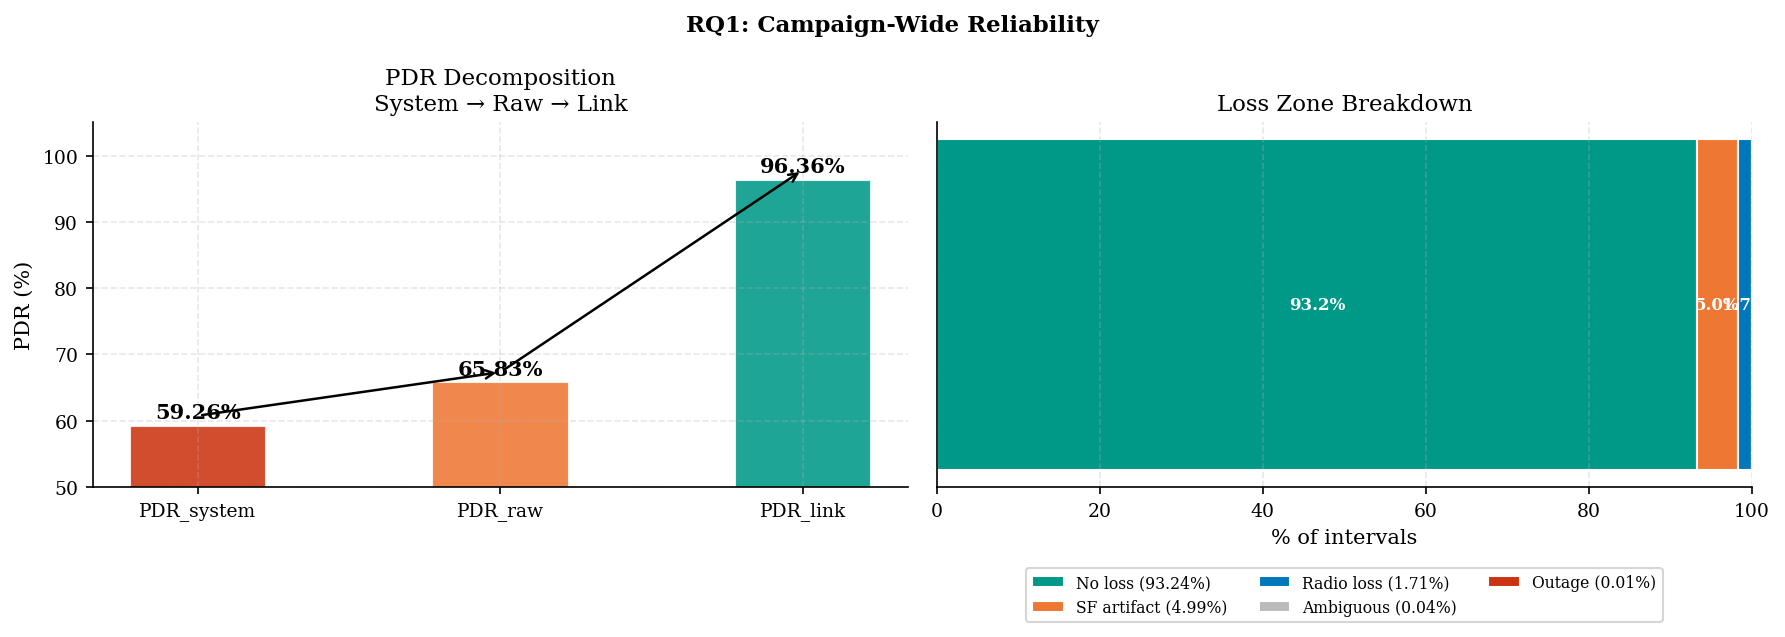

In [4]:
# Fig 03-A — PDR Decomposition + Loss Zone
rx=len(df); lost_sys=int(df['total_loss'].sum())
lost_raw=int(df['mac_to_radio_loss'].sum())
lost_lnk=int(df_link['mac_to_radio_loss'].sum())
ps=rx/(rx+lost_sys)*100; pr=rx/(rx+lost_raw)*100
pl=len(df_link)/(len(df_link)+lost_lnk)*100

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
# PDR bars
labs=['PDR_system','PDR_raw','PDR_link']
vals=[ps,pr,pl]; cols=[C['red'],C['orange'],C['green']]
bars=axes[0].bar(labs,vals,color=cols,width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,vals):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+0.5,f'{v:.2f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
for i in range(len(vals)-1):
    axes[0].annotate('',xy=(i+1,vals[i+1]+1.5),xytext=(i,vals[i]+1.5),
                     arrowprops=dict(arrowstyle='->',color='black',lw=1.2))
axes[0].set_ylabel('PDR (%)'); axes[0].set_ylim(50,105)
axes[0].set_title('PDR Decomposition\nSystem → Raw → Link')

# Zone stacked bar
zones=['no_loss','sf_artifact','radio_loss','ambiguous','outage']
zlabs=['No loss','SF artifact','Radio loss','Ambiguous','Outage']
zcols=[C['green'],C['orange'],C['blue'],C['grey'],C['red']]
counts=df['loss_zone'].value_counts().reindex(zones).fillna(0)
pcts=counts/len(df)*100
left=0
for zone,label,color in zip(zones,zlabs,zcols):
    w=pcts[zone]
    axes[1].barh(0,w,left=left,color=color,edgecolor='white',height=0.5,label=f'{label} ({w:.2f}%)')
    if w>1.2: axes[1].text(left+w/2,0,f'{w:.1f}%',ha='center',va='center',fontsize=8,fontweight='bold',color='white')
    left+=w
axes[1].set_xlim(0,100); axes[1].set_yticks([])
axes[1].set_xlabel('% of intervals')
axes[1].set_title('Loss Zone Breakdown')
axes[1].legend(loc='upper center',bbox_to_anchor=(0.5,-0.2),ncol=3,fontsize=7.5)

fig.suptitle('RQ1: Campaign-Wide Reliability', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_a_rq1_overview')


## 2 · Per-Device PDR_Link Summary  *(Table 7.1)*

PDR_link per device — the metric used for all event-conditioned analysis.  
The near-uniform PDR across vastly different link budgets is the first evidence  
for the collision-dominated loss hypothesis.

In [5]:
print(f"{'Device':<8} {'Dist(m)':^8} {'CW':^4} {'WW':^4} {'Received':^10} "
      f"{'Link Lost':^11} {'PDR_link':^10}")
print('-' * 65)

pdrs = {}
for dev, g in df_link.groupby('device_id'):
    rx = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    pdrs[dev] = pdr
    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])
    print(f"{dev:<8} {dist:^8} {cw:^4} {ww:^4} {rx:^10,} {lost:^11,} {pdr:^10.2f}%")

print('-' * 65)
pdr_range = max(pdrs.values()) - min(pdrs.values())
print(f"PDR range across devices: {pdr_range:.2f} percentage points")
print(f"\nKey observation: {pdr_range:.2f} percentage points spread across devices with very different distances")
print(f"""
- link budgets (10m direct LoS to 40m through 4 walls) — consistent with collision-dominated losses rather than signal quality degradation.
- ED4 is 37m away through 5 walls. ED0 is 10m away with nothing in between. Signal quality theory predicts ED4 should have dramatically lower PDR.
- Instead the difference is 0.43 percentage points (96.39 - 95.96). That is essentially zero.
- If signal quality drove losses, you would see 10-20 percentage points difference.
- 0.80 pp across the whole deployment means something else entirely drives losses — and that something is shared channel collisions,
    which affect all devices equally regardless of their individual link budget.
"""
      )

Device   Dist(m)   CW   WW   Received   Link Lost   PDR_link 
-----------------------------------------------------------------
ED0         10     0    0    192,030      7,185      96.39   %
ED1         8      1    0    191,072      7,547      96.20   %
ED2         23     0    2    193,876      6,479      96.77   %
ED3         18     1    2    190,340      7,652      96.14   %
ED4         37     0    5    189,995      7,996      95.96   %
ED5         40     2    2    199,094      6,848      96.67   %
-----------------------------------------------------------------
PDR range across devices: 0.80 percentage points

Key observation: 0.80 percentage points spread across devices with very different distances

- link budgets (10m direct LoS to 40m through 4 walls) — consistent with collision-dominated losses rather than signal quality degradation.
- ED4 is 37m away through 5 walls. ED0 is 10m away with nothing in between. Signal quality theory predicts ED4 should have dramatically lower PDR

  Saved: 03_b1_rolling_pdr_individual_7D


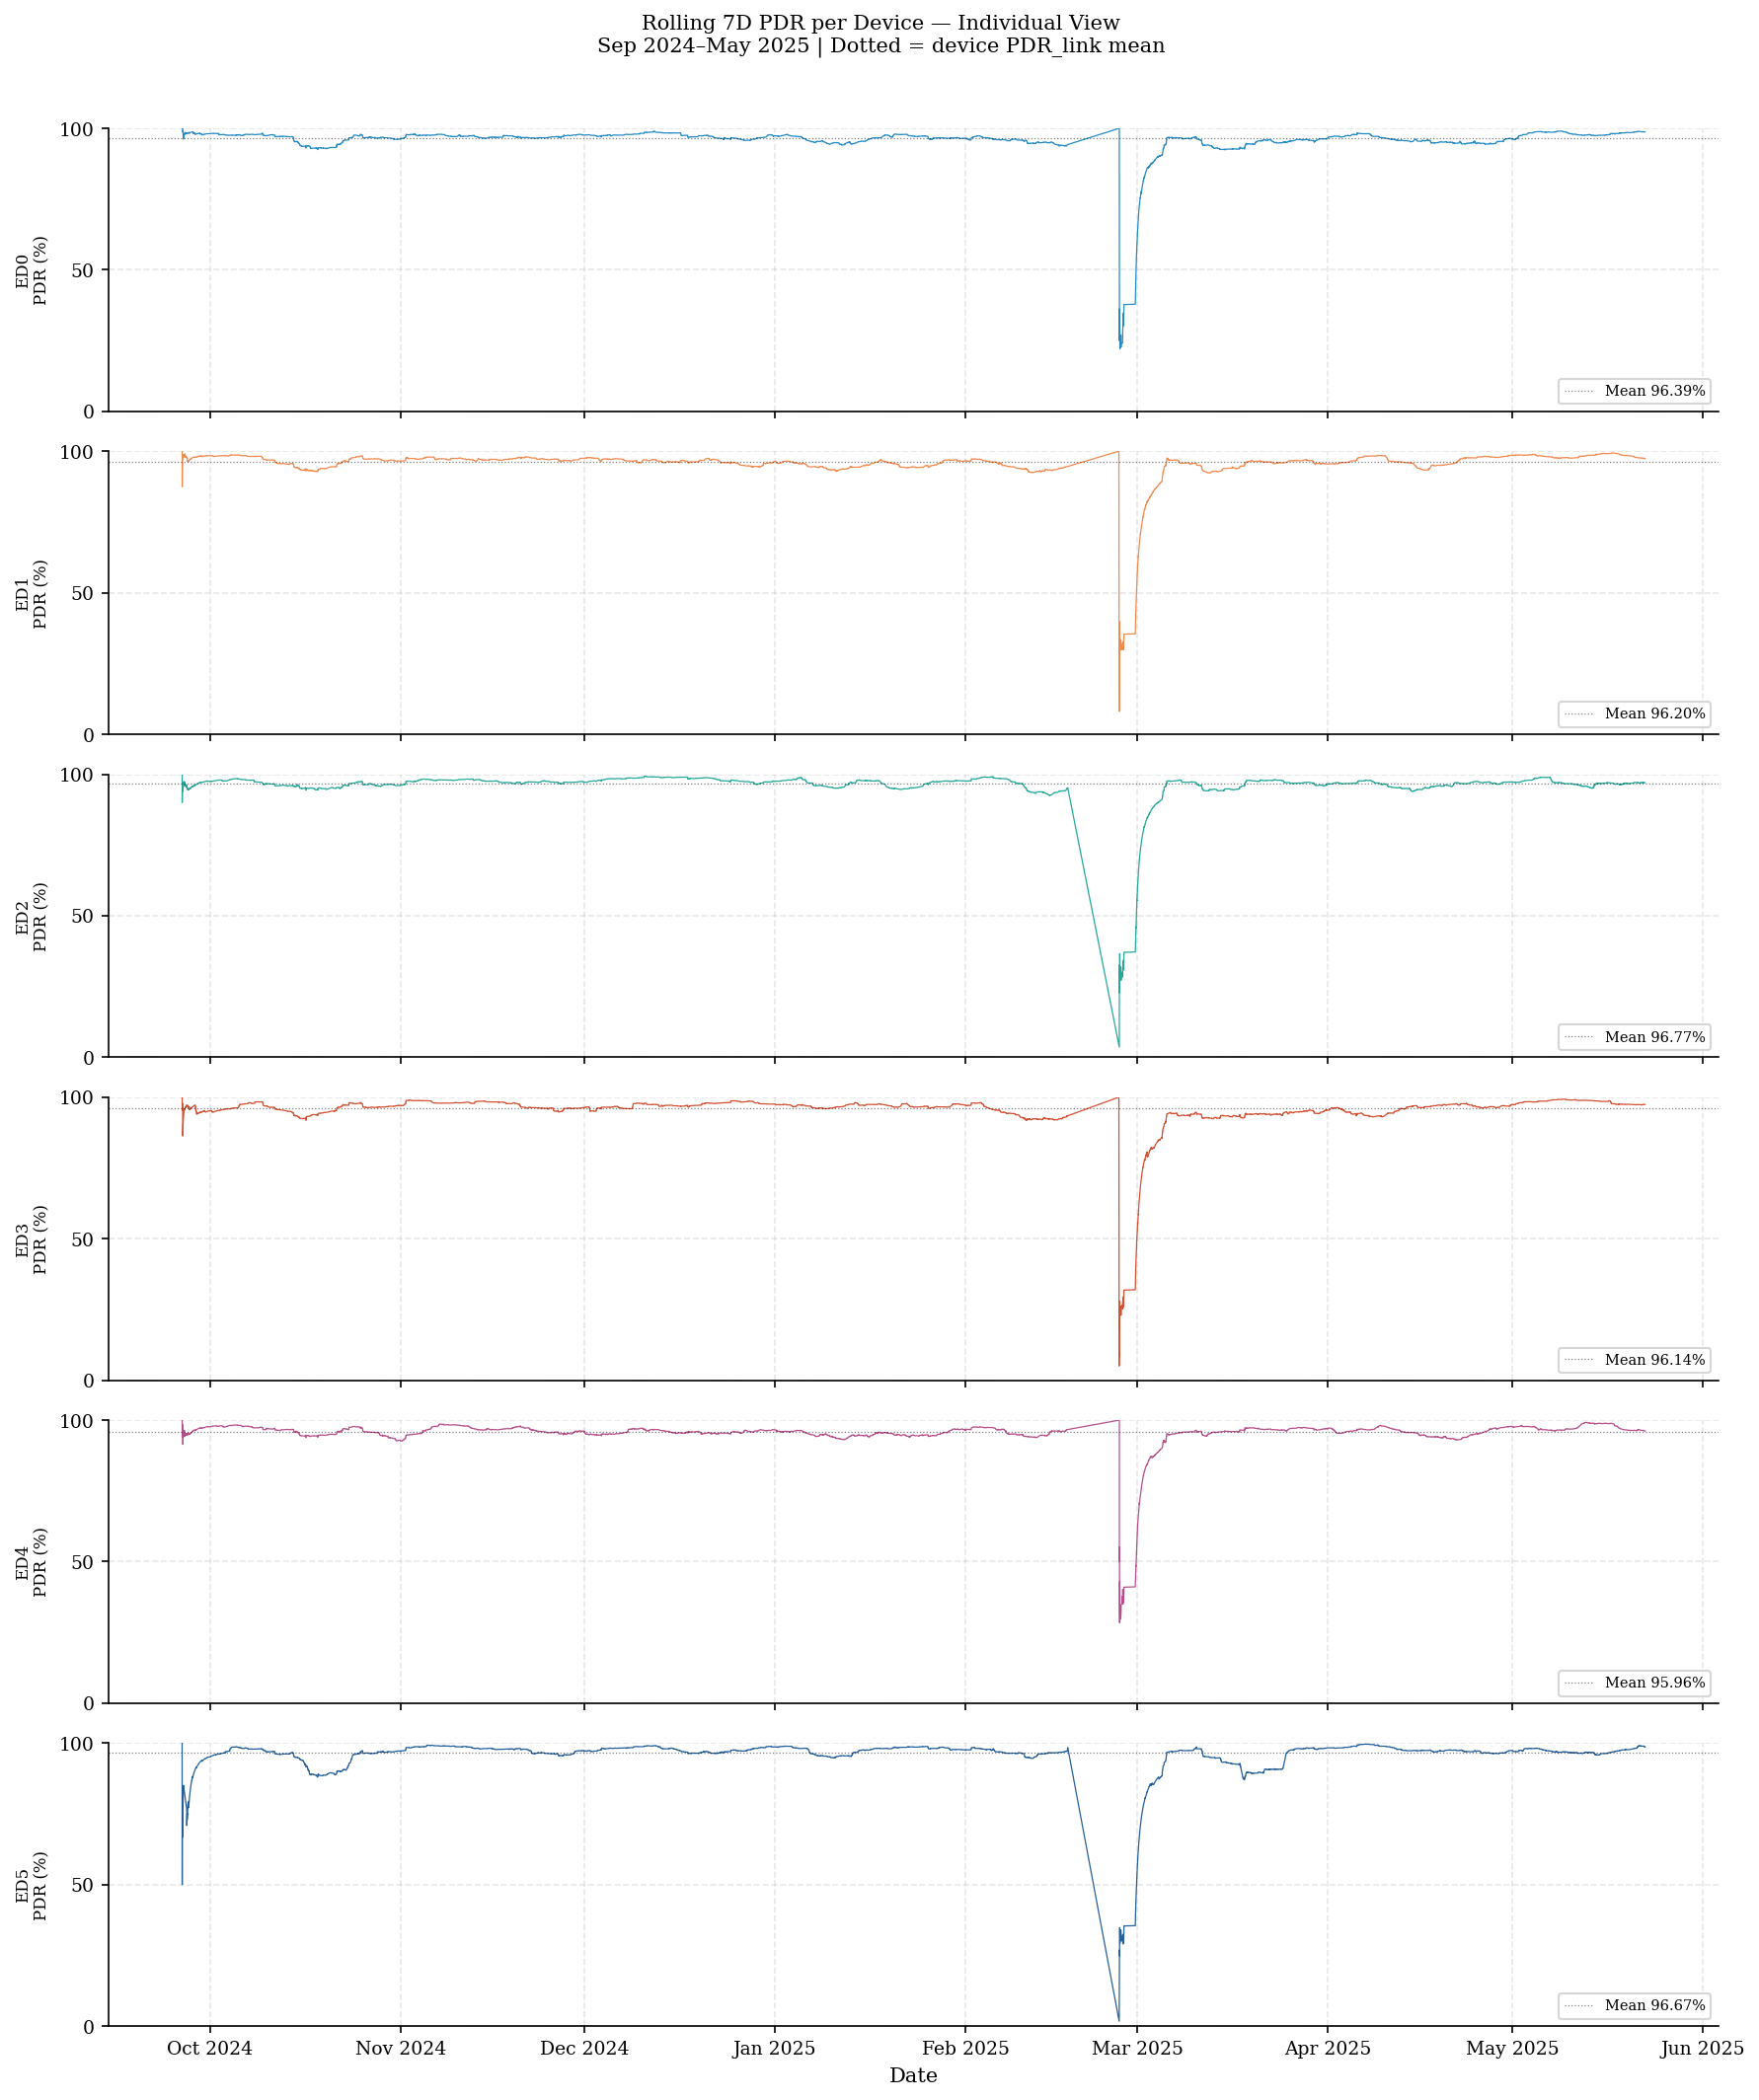

  Saved: 03_b2_rolling_pdr_superimposed_7D


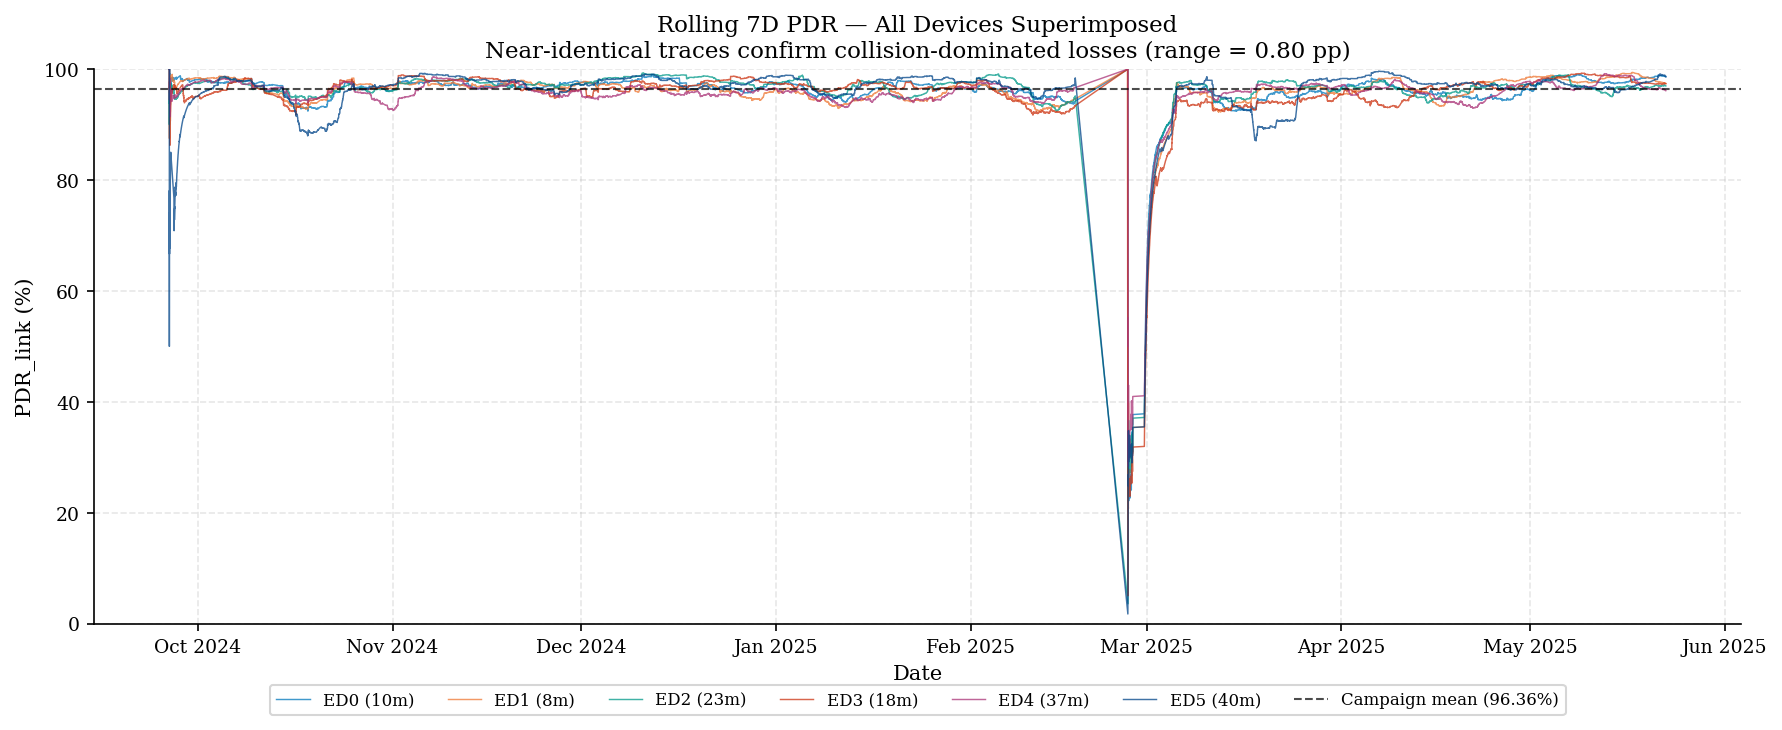

In [8]:
# Fig 03-B — Rolling PDR Time Series
ROLLING_WINDOW = '24h'   # change here only — '30min' | '2h' | '24h' | '7D'
# ROLLING_WINDOW = '7D'

DEVICES_A = sorted(df_link['device_id'].unique())

# ── Figure 1: individual subplots per device ─────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)
for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id']==dev].copy().set_index('time').sort_index()
    g['rx1'] = 1
    rpdr = (g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum() /
            g['total_tx'].rolling(ROLLING_WINDOW, min_periods=1).sum() * 100).clip(0, 100)
    axes[i].plot(rpdr.index, rpdr.values, linewidth=0.6,
                 color=DEVICE_COLORS[i], alpha=0.85)
    pdr_lnk = (len(df_link[df_link['device_id']==dev]) /
               (len(df_link[df_link['device_id']==dev]) +
                int(df_link[df_link['device_id']==dev]['mac_to_radio_loss'].sum())) * 100)
    axes[i].axhline(y=pdr_lnk, color='black', lw=0.6, ls=':', alpha=0.5,
                    label=f'Mean {pdr_lnk:.2f}%')
    axes[i].set_ylabel(f'{dev}\nPDR (%)', fontsize=8)
    axes[i].set_ylim(0, 100)
    axes[i].set_yticks([0, 50, 100])
    axes[i].legend(fontsize=7, loc='lower right')

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.suptitle(f'Rolling {ROLLING_WINDOW} PDR per Device — Individual View\n'
             f'Sep 2024–May 2025 | Dotted = device PDR_link mean',
             fontsize=10, y=1.01)
fig.tight_layout()
save_fig(fig, f'03_b1_rolling_pdr_individual_{ROLLING_WINDOW}')

# ── Figure 2: all devices superimposed on one axis ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for i, dev in enumerate(DEVICES_A):
    g = df_link[df_link['device_id']==dev].copy().set_index('time').sort_index()
    g['rx1'] = 1
    rpdr = (g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum() /
            g['total_tx'].rolling(ROLLING_WINDOW, min_periods=1).sum() * 100).clip(0, 100)
    dist = int(df_link[df_link['device_id']==dev]['distance'].iloc[0])
    ax.plot(rpdr.index, rpdr.values, linewidth=0.7,
            color=DEVICE_COLORS[i], alpha=0.75,
            label=f'{dev} ({dist}m)')

# campaign mean PDR_link across all devices
pdr_link_all = (len(df_link) /
                (len(df_link) + int(df_link['mac_to_radio_loss'].sum())) * 100)
ax.axhline(y=pdr_link_all, color='black', lw=1.0, ls='--', alpha=0.7,
           label=f'Campaign mean ({pdr_link_all:.2f}%)')

ax.set_ylabel('PDR_link (%)')
ax.set_xlabel('Date')
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
ax.legend(ncol=7, loc='lower center', bbox_to_anchor=(0.5, -0.18), fontsize=8)
ax.set_title(f'Rolling {ROLLING_WINDOW} PDR — All Devices Superimposed\n'
             f'Near-identical traces confirm collision-dominated losses '
             f'(range = {max(pdrs.values())-min(pdrs.values()):.2f} pp)')

fig.tight_layout()
save_fig(fig, f'03_b2_rolling_pdr_superimposed_{ROLLING_WINDOW}')

## 3 · Statistical Analysis Core Function  *(§5.5.1)*

All event-conditioned comparisons use the same statistical framework:

1. **PDR computation** — for each event condition, compute mean PDR
2. **Mann-Whitney U test** — nonparametric test on `total_tx` distributions  
   (chosen because loss values are discrete and non-normal)
3. **Effect size** — rank-biserial correlation r = 1 − 2U/(n₁n₂)  
   ranges from -1 (event group has lower PDR) to +1 (event group has higher PDR)
4. **Significance** — α = 0.05 two-sided

This function is called for every binary event comparison in sections 4–8.

In [9]:
def pdr_compare(df_in, event_col, group1_label, group0_label=None):
    """
    Compare PDR between two event groups.
    Returns dict with PDR values, Mann-Whitney U test, and effect size.
    """
    g1 = df_in[df_in[event_col] == group1_label]
    g0 = df_in[df_in[event_col] != group1_label] if group0_label is None \
        else df_in[df_in[event_col] == group0_label]

    def pdr(g):
        rx = len(g)
        lost = int(g['mac_to_radio_loss'].sum())
        return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0

    pdr1, pdr0 = pdr(g1), pdr(g0)
    diff = pdr1 - pdr0

    # Mann-Whitney U on total_tx — tests whether loss distributions differ
    stat, p = stats.mannwhitneyu(
        g1['total_tx'].values, g0['total_tx'].values, alternative='two-sided'
    )
    n1, n0 = len(g1), len(g0)
    r = 1 - 2 * stat / (n1 * n0)  # rank-biserial correlation

    return {
        'group1': group1_label, 'n1': n1, 'pdr1': pdr1,
        'group0': group0_label or f'not {group1_label}', 'n0': n0, 'pdr0': pdr0,
        'diff_pp': diff, 'p_value': p, 'effect_r': r,
        'significant': p < 0.05
    }


def print_comparison(result, title=''):
    sig = '✓ SIGNIFICANT' if result['significant'] else '✗ not significant'
    print(f"  {title}")
    print(f"    {result['group1']:>20}: {result['pdr1']:.2f}%  (n={result['n1']:,})")
    print(f"    {result['group0']:>20}: {result['pdr0']:.2f}%  (n={result['n0']:,})")
    print(f"    Difference        : {result['diff_pp']:+.2f} pp")
    print(f"    p-value           : {result['p_value']:.4f}  {sig}")
    print(f"    Effect size (r)   : {result['effect_r']:.4f}")
    print()


print('Statistical framework ready.')
print('Mann-Whitney U + rank-biserial correlation for all event comparisons.')

Statistical framework ready.
Mann-Whitney U + rank-biserial correlation for all event comparisons.


## 4 · Occupancy-Conditioned Reliability  *(§7.4 — RQ2)*

**Hypothesis:** Higher CO₂ (more people) → more RF interference → lower PDR.  
CO₂ is the primary occupancy proxy. This is the most important environmental event family.

Occupancy events: E1 (CO₂ tier), E2 (CO₂ rising)

In [10]:
print('=' * 60)
print('OCCUPANCY EVENTS — CO2 (§7.4)')
print('=' * 60)

occupancy_results = {}

# E1: CO2 tier — three-way comparison
print('\nE1: CO2 Tier PDR')
co2_pdrs = {}
for tier in ['background', 'moderate', 'high']:
    g = df_link[df_link['e1_co2_tier'] == tier]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    co2_pdrs[tier] = pdr
    print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# key comparison: high vs background
print('\nE1: High vs Background CO2 (key comparison)')
r = pdr_compare(df_link, 'e1_co2_tier', 'high', 'background')
print_comparison(r, 'High CO2 vs Background')
occupancy_results['E1_high_vs_bg'] = r

# moderate vs background
r = pdr_compare(df_link, 'e1_co2_tier', 'moderate', 'background')
print_comparison(r, 'Moderate CO2 vs Background')
occupancy_results['E1_mod_vs_bg'] = r

# E2: CO2 rising
print('E2: CO2 Rising vs Stable')
r = pdr_compare(df_link, 'e2_co2_rising', 1, 0)
print_comparison(r, 'CO2 rising (1) vs stable (0)')
occupancy_results['E2_rising'] = r

print('''
E3 is very dominant because:
During the brief transition moments when occupancy is actively increasing, the radio channel
becomes extremely congested — probably because many devices activate simultaneously (laptops connecting,
phones reconnecting to WiFi, IoT sensors waking up) creating a sudden collision burst.
''')


OCCUPANCY EVENTS — CO2 (§7.4)

E1: CO2 Tier PDR
    background  : 96.84%  (n=597,487)
    moderate    : 96.30%  (n=416,678)
    high        : 94.57%  (n=142,242)

E1: High vs Background CO2 (key comparison)
  High CO2 vs Background
                    high: 94.57%  (n=142,242)
              background: 96.84%  (n=597,487)
    Difference        : -2.27 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0096

  Moderate CO2 vs Background
                moderate: 96.30%  (n=416,678)
              background: 96.84%  (n=597,487)
    Difference        : -0.54 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0024

E2: CO2 Rising vs Stable
  CO2 rising (1) vs stable (0)
                       1: 33.48%  (n=1,087)
                   not 1: 96.53%  (n=1,155,320)
    Difference        : -63.05 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.3227


E3 is very dominant because:
During the brief transition moments when

  Saved: fig_03c_occupancy_pdr


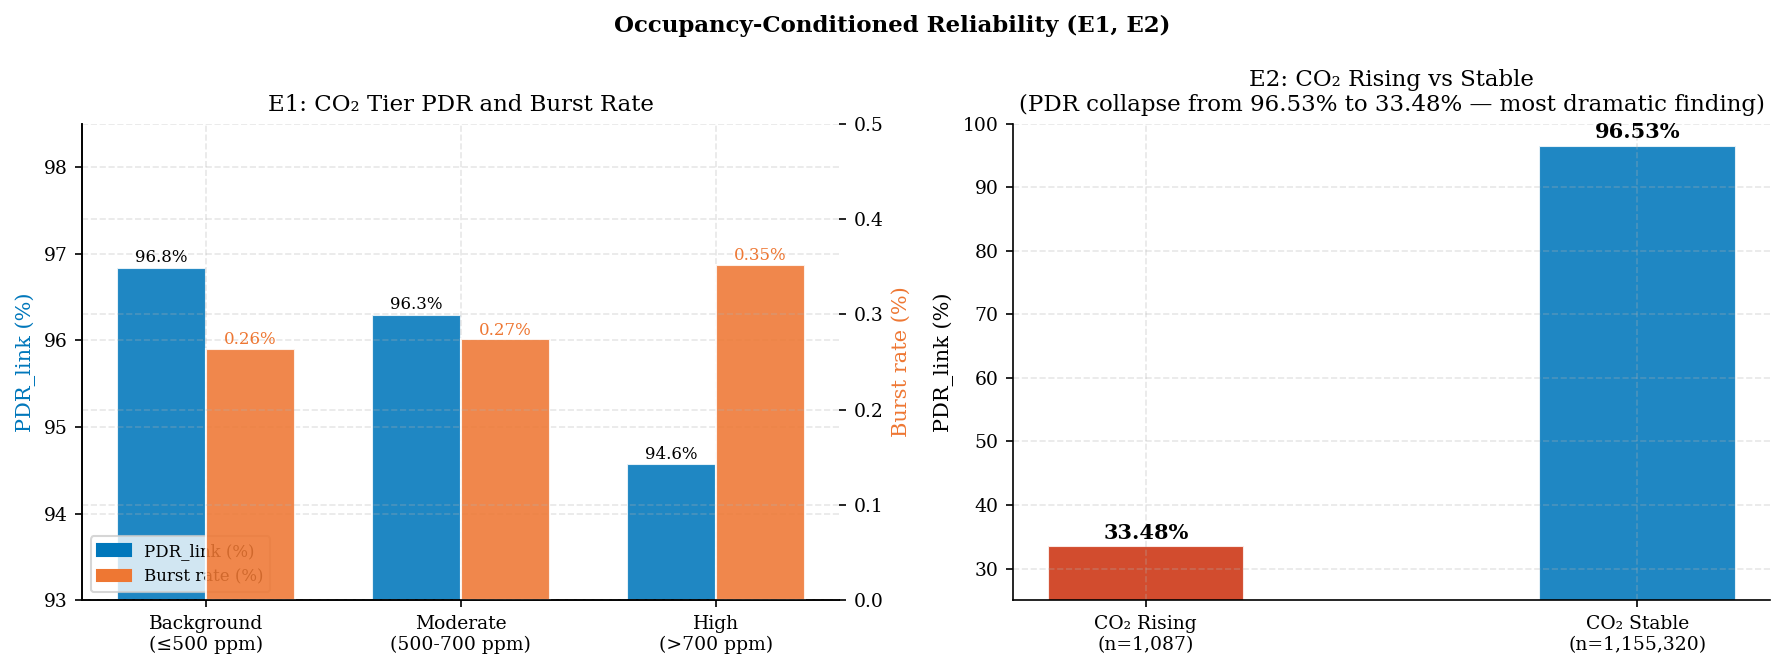

In [14]:
# Fig 03-C — Occupancy Events: CO2 Tier + CO2 Rising
tiers=['background','moderate','high']
xlabs_c=['Background\n(\u2264500 ppm)','Moderate\n(500-700 ppm)','High\n(>700 ppm)']
pdrs_c=[pdr_grp(df_link[df_link['e1_co2_tier']==t]) for t in tiers]
bursts_c=[burst_rate_grp(df_link[df_link['e1_co2_tier']==t]) for t in tiers]
g1=df_link[df_link['e2_co2_rising']==1]; g0=df_link[df_link['e2_co2_rising']==0]

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
x=np.arange(len(tiers)); w=0.35
ax2=axes[0].twinx()
b1=axes[0].bar(x-w/2,pdrs_c,w,color=C['blue'],alpha=0.88,label='PDR_link (%)',edgecolor='white')
b2=ax2.bar(x+w/2,bursts_c,w,color=C['orange'],alpha=0.88,label='Burst rate (%)',edgecolor='white')
for bar,v in zip(b1,pdrs_c): axes[0].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.1f}%',ha='center',va='bottom',fontsize=8)
for bar,v in zip(b2,bursts_c): ax2.text(bar.get_x()+bar.get_width()/2,v+0.001,f'{v:.2f}%',ha='center',va='bottom',fontsize=8,color=C['orange'])
axes[0].set_xticks(x); axes[0].set_xticklabels(xlabs_c)
axes[0].set_ylabel('PDR_link (%)',color=C['blue']); ax2.set_ylabel('Burst rate (%)',color=C['orange'])
axes[0].set_ylim(93,98.5); ax2.set_ylim(0,0.5)
axes[0].set_title('E1: CO\u2082 Tier PDR and Burst Rate')
axes[0].legend(handles=[mpatches.Patch(color=C['blue'],label='PDR_link (%)'),
               mpatches.Patch(color=C['orange'],label='Burst rate (%)')],loc='lower left',fontsize=8)

axes[1].bar(['CO\u2082 Rising\n(n=1,087)','CO\u2082 Stable\n(n=1,155,320)'],
             [pdr_grp(g1),pdr_grp(g0)],color=[C['red'],C['blue']],width=0.4,alpha=0.88,edgecolor='white')
for i,(v,lbl) in enumerate(zip([pdr_grp(g1),pdr_grp(g0)],['CO\u2082 Rising','CO\u2082 Stable'])):
    axes[1].text(i,v+0.5,f'{v:.2f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')
axes[1].set_ylabel('PDR_link (%)'); axes[1].set_ylim(25,100)
axes[1].set_title('E2: CO\u2082 Rising vs Stable\n(PDR collapse from 96.53% to 33.48% — most dramatic finding)')

fig.suptitle('Occupancy-Conditioned Reliability (E1, E2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, 'fig_03_c_occupancy_pdr')


## 5 · Temporal Event-Conditioned Reliability  *(§7.3 — RQ2)*

**Hypothesis:** Office hours and weekdays should show lower PDR than off-peak periods  
due to higher human activity and increased RF interference from electronic devices.

Temporal events: E3 (weekday), E4 (time-of-day), E5 (office hours), E6 (season)

In [15]:
print('=' * 60)
print('TEMPORAL EVENTS (§7.3)')
print('=' * 60)

temporal_results = {}

# E3: weekday vs weekend
print('\nE3: Weekday vs Weekend')
r = pdr_compare(df_link, 'e3_is_weekday', 1, 0)
print_comparison(r, 'Weekday (1) vs Weekend (0)')
temporal_results['E3_weekday'] = r

# E4: time-of-day bands
print('E4: Time-of-Day PDR')
for band in ['night', 'morning', 'peak', 'evening']:
    g = df_link[df_link['e4_time_of_day'] == band]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {band:<10}: {pdr:.2f}%  (n={rx:,})')

# E5: office hours binary
print('\nE5: Office Hours vs Off-Peak')
r = pdr_compare(df_link, 'e5_office_hours', 1, 0)
print_comparison(r, 'Office hours (1) vs off-peak (0)')
temporal_results['E5_office'] = r

# E6: season
print('E6: Season PDR')
for season in ['autumn', 'winter', 'spring']:
    g = df_link[df_link['e6_season'] == season]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    print(f'    {season:<10}: {pdr:.2f}%  (n={rx:,})')

TEMPORAL EVENTS (§7.3)

E3: Weekday vs Weekend
  Weekday (1) vs Weekend (0)
                       1: 96.09%  (n=820,283)
                   not 1: 97.03%  (n=336,124)
    Difference        : -0.94 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0024

E4: Time-of-Day PDR
    night     : 96.57%  (n=290,860)
    morning   : 96.87%  (n=290,376)
    peak      : 95.94%  (n=285,538)
    evening   : 96.05%  (n=289,633)

E5: Office Hours vs Off-Peak
  Office hours (1) vs off-peak (0)
                       1: 95.36%  (n=338,049)
                   not 1: 96.78%  (n=818,358)
    Difference        : -1.42 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0048

E6: Season PDR
    autumn    : 96.70%  (n=328,214)
    winter    : 95.99%  (n=407,201)
    spring    : 96.45%  (n=420,992)


  Saved: 03_d_temporal_pdr


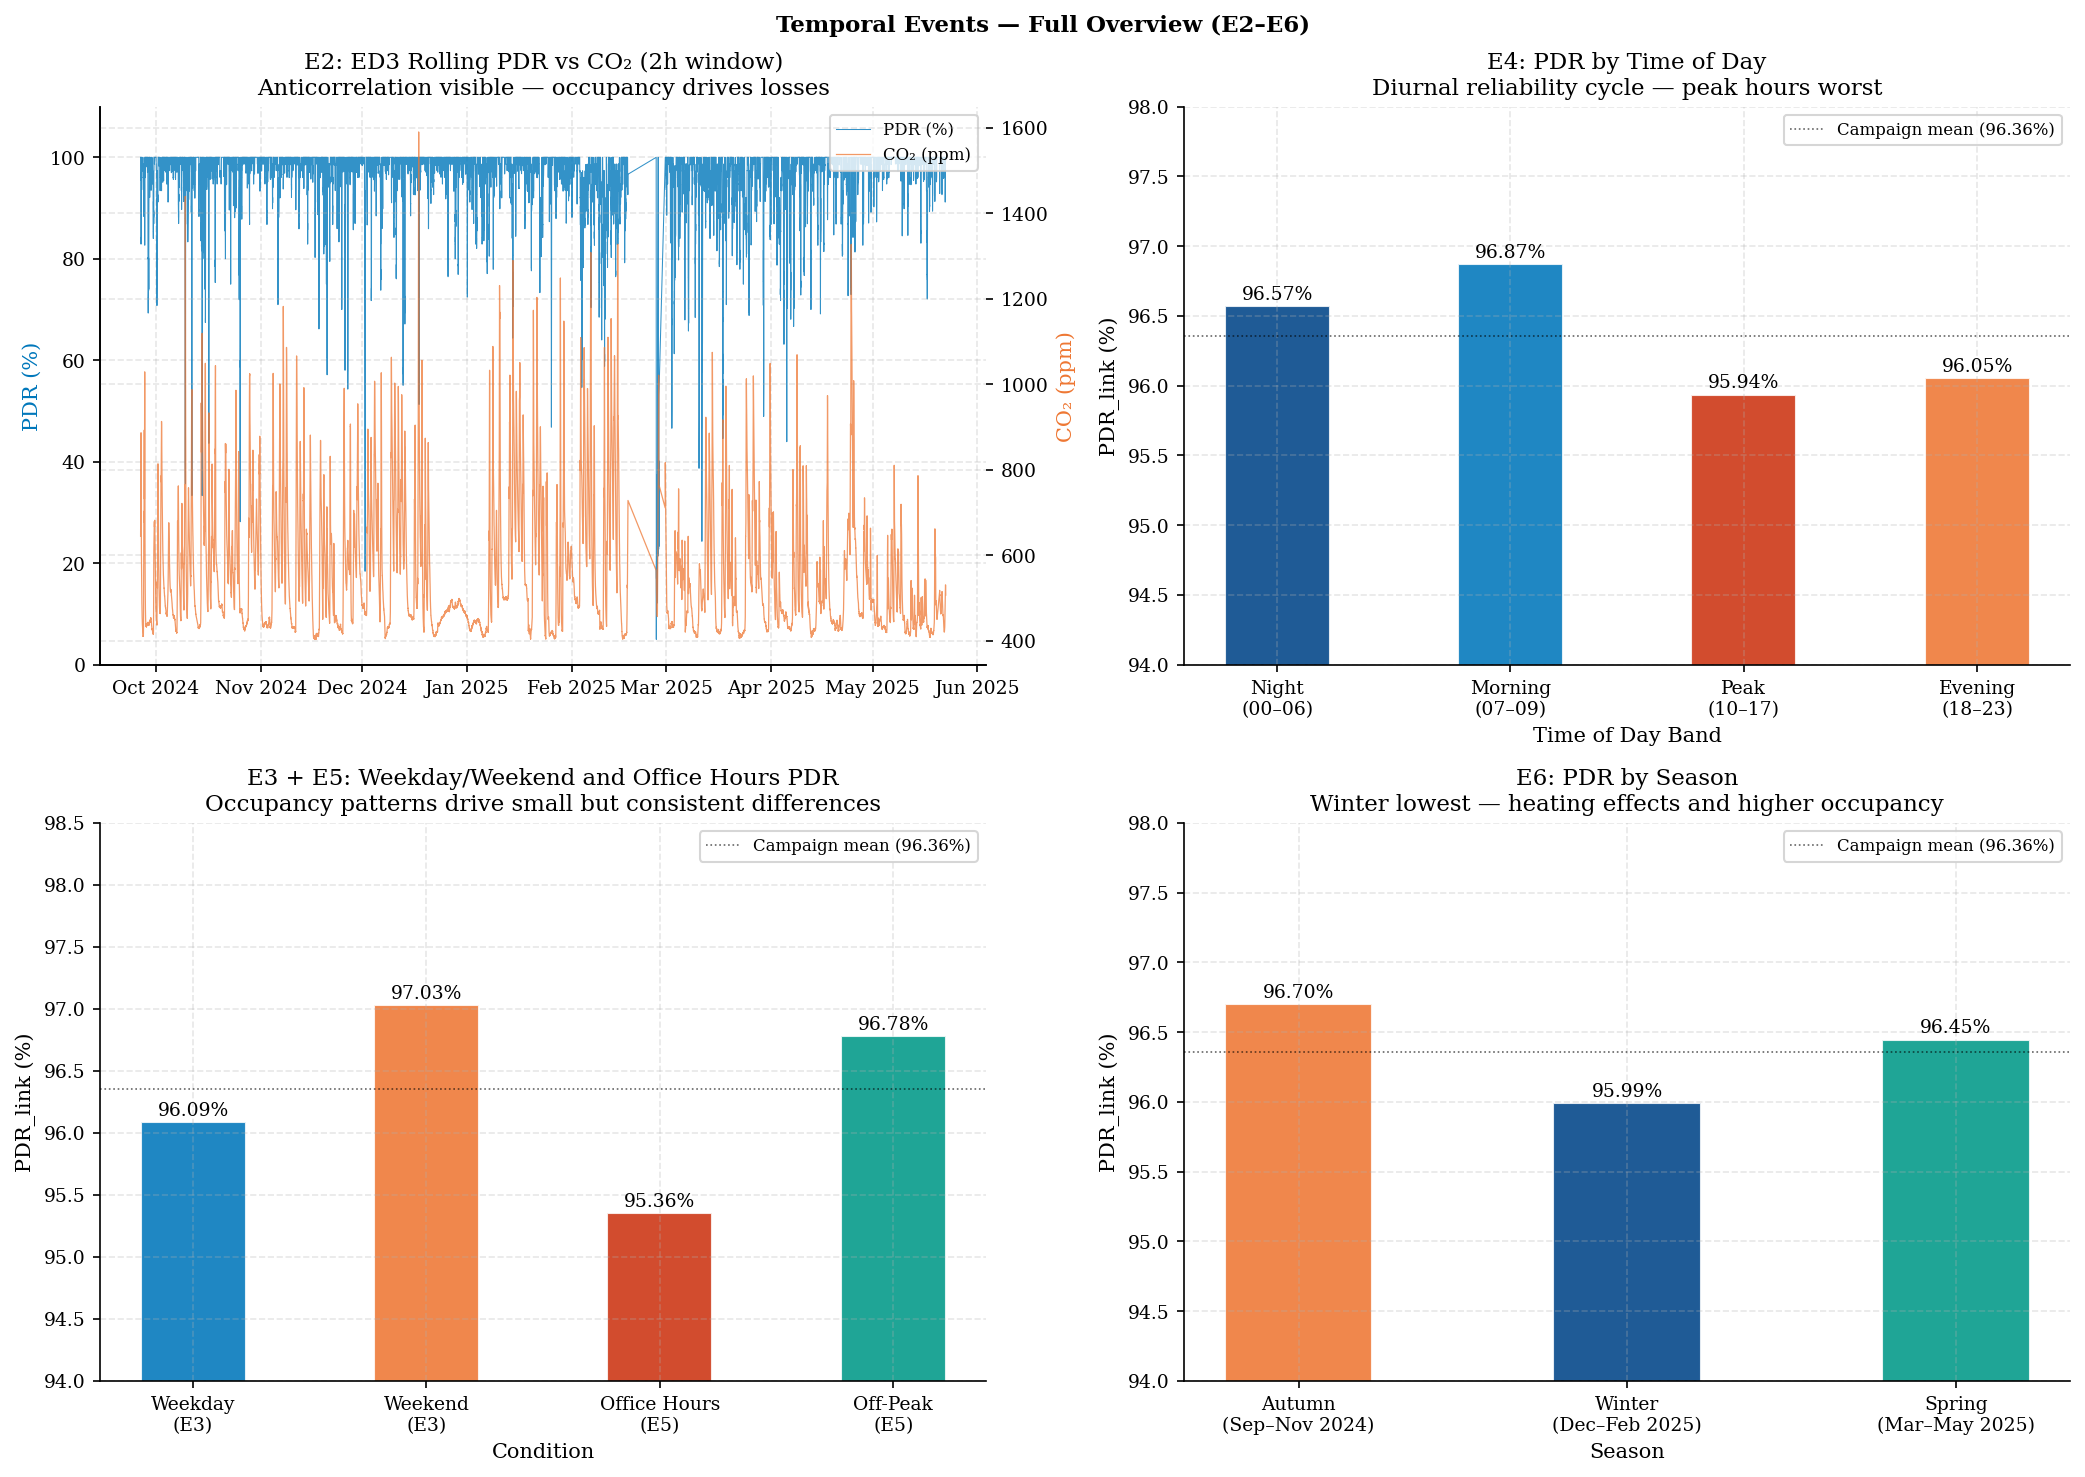

In [19]:
# Fig 03-D — Temporal Events: CO₂-PDR + Diurnal + Weekday + Season
ROLLING_WINDOW_CO2 = '2h'

dev = 'ED3'
g = df_link[df_link['device_id']==dev].copy().set_index('time').sort_index()
g['rx1'] = 1
rpdr = (g['rx1'].rolling(ROLLING_WINDOW_CO2, min_periods=1).sum() /
        g['total_tx'].rolling(ROLLING_WINDOW_CO2, min_periods=1).sum() * 100).clip(0, 100)
rco2 = g['co2'].rolling(ROLLING_WINDOW_CO2, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# top-left: CO₂ vs rolling PDR dual axis (E2)
ax2 = axes[0,0].twinx()
axes[0,0].plot(rpdr.index, rpdr.values, color=C['blue'], linewidth=0.5, alpha=0.8, label='PDR (%)')
ax2.plot(rco2.index, rco2.values, color=C['orange'], linewidth=0.6, alpha=0.75, label='CO₂ (ppm)')
axes[0,0].set_ylabel('PDR (%)', color=C['blue'])
ax2.set_ylabel('CO₂ (ppm)', color=C['orange'])
axes[0,0].set_ylim(0, 110)
axes[0,0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
l1,lb1 = axes[0,0].get_legend_handles_labels()
l2,lb2 = ax2.get_legend_handles_labels()
axes[0,0].legend(l1+l2, lb1+lb2, loc='upper right', fontsize=8)
axes[0,0].set_title(f'E2: {dev} Rolling PDR vs CO₂ ({ROLLING_WINDOW_CO2} window)\nAnticorrelation visible — occupancy drives losses')

# top-right: E4 time of day
bands = ['night','morning','peak','evening']
blabs = ['Night\n(00–06)','Morning\n(07–09)','Peak\n(10–17)','Evening\n(18–23)']
pdrs_t = [pdr_grp(df_link[df_link['e4_time_of_day']==b]) for b in bands]
bars = axes[0,1].bar(blabs, pdrs_t,
                      color=[C['navy'],C['blue'],C['red'],C['orange']],
                      width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pdrs_t):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.02,
                   f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[0,1].set_ylabel('PDR_link (%)')
axes[0,1].set_xlabel('Time of Day Band')
axes[0,1].set_ylim(94, 98)
axes[0,1].axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6,
                   label=f'Campaign mean ({pdr_grp(df_link):.2f}%)')
axes[0,1].legend(fontsize=8)
axes[0,1].set_title('E4: PDR by Time of Day\nDiurnal reliability cycle — peak hours worst')

# bottom-left: E3 + E5 weekday/weekend and office hours
categories = ['Weekday\n(E3)','Weekend\n(E3)','Office Hours\n(E5)','Off-Peak\n(E5)']
pdr_wk  = pdr_grp(df_link[df_link['e3_is_weekday']==1])
pdr_we  = pdr_grp(df_link[df_link['e3_is_weekday']==0])
pdr_oh  = pdr_grp(df_link[df_link['e5_office_hours']==1])
pdr_op  = pdr_grp(df_link[df_link['e5_office_hours']==0])
vals_35 = [pdr_wk, pdr_we, pdr_oh, pdr_op]
colors_35 = [C['blue'], C['orange'], C['red'], C['green']]
bars = axes[1,0].bar(categories, vals_35, color=colors_35,
                      width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, vals_35):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.02,
                   f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1,0].set_ylabel('PDR_link (%)')
axes[1,0].set_xlabel('Condition')
axes[1,0].set_ylim(94, 98.5)
axes[1,0].axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6,
                   label=f'Campaign mean ({pdr_grp(df_link):.2f}%)')
axes[1,0].legend(fontsize=8)
axes[1,0].set_title('E3 + E5: Weekday/Weekend and Office Hours PDR\nOccupancy patterns drive small but consistent differences')

# bottom-right: E6 season
seasons = ['autumn','winter','spring']
slabs   = ['Autumn\n(Sep–Nov 2024)','Winter\n(Dec–Feb 2025)','Spring\n(Mar–May 2025)']
pdrs_s  = [pdr_grp(df_link[df_link['e6_season']==s]) for s in seasons]
bars = axes[1,1].bar(slabs, pdrs_s,
                      color=[C['orange'],C['navy'],C['green']],
                      width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, pdrs_s):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.02,
                   f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
axes[1,1].set_ylabel('PDR_link (%)')
axes[1,1].set_xlabel('Season')
axes[1,1].set_ylim(94, 98)
axes[1,1].axhline(y=pdr_grp(df_link), color='black', lw=0.8, ls=':', alpha=0.6,
                   label=f'Campaign mean ({pdr_grp(df_link):.2f}%)')
axes[1,1].legend(fontsize=8)
axes[1,1].set_title('E6: PDR by Season\nWinter lowest — heating effects and higher occupancy')

fig.suptitle('Temporal Events — Full Overview (E2–E6)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_d_temporal_pdr')

## 6a · Air Quality Events — PM2.5  *(§7.5.1 — RQ2)*

PM2.5 spikes mark activity bursts — cleaning, printing, cooking.  
Device-specific 90th percentile thresholds (E7) account for location differences:  
ED4 (server room) baseline = 0.79 µg/m³ vs ED5 (kitchen) = 6.28 µg/m³.

In [20]:
print('=' * 60)
print('AIR QUALITY EVENTS — PM2.5 (§7.5.1)')
print('=' * 60)

atm_results = {}

# E7: PM2.5 spike
print('\nE7: PM2.5 Spike (device-specific 90th percentile)')
r = pdr_compare(df_link, 'e7_pm25_spike', 1, 0)
print_comparison(r, 'PM2.5 spike (1) vs normal (0)')
atm_results['E7_spike'] = r

# E8: PM2.5 absolute tier
print('E8: PM2.5 Absolute Tier')
for tier in ['clean', 'moderate', 'elevated']:
    g = df_link[df_link['e8_pm25_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

AIR QUALITY EVENTS — PM2.5 (§7.5.1)

E7: PM2.5 Spike (device-specific 90th percentile)
  PM2.5 spike (1) vs normal (0)
                       1: 94.28%  (n=115,186)
                   not 1: 96.59%  (n=1,041,221)
    Difference        : -2.31 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0153

E8: PM2.5 Absolute Tier
    clean     : 96.65%  (n=799,081)
    moderate  : 95.99%  (n=343,389)
    elevated  : 89.36%  (n=13,937)


  Saved: fig_03e_air_atmospheric_pdr


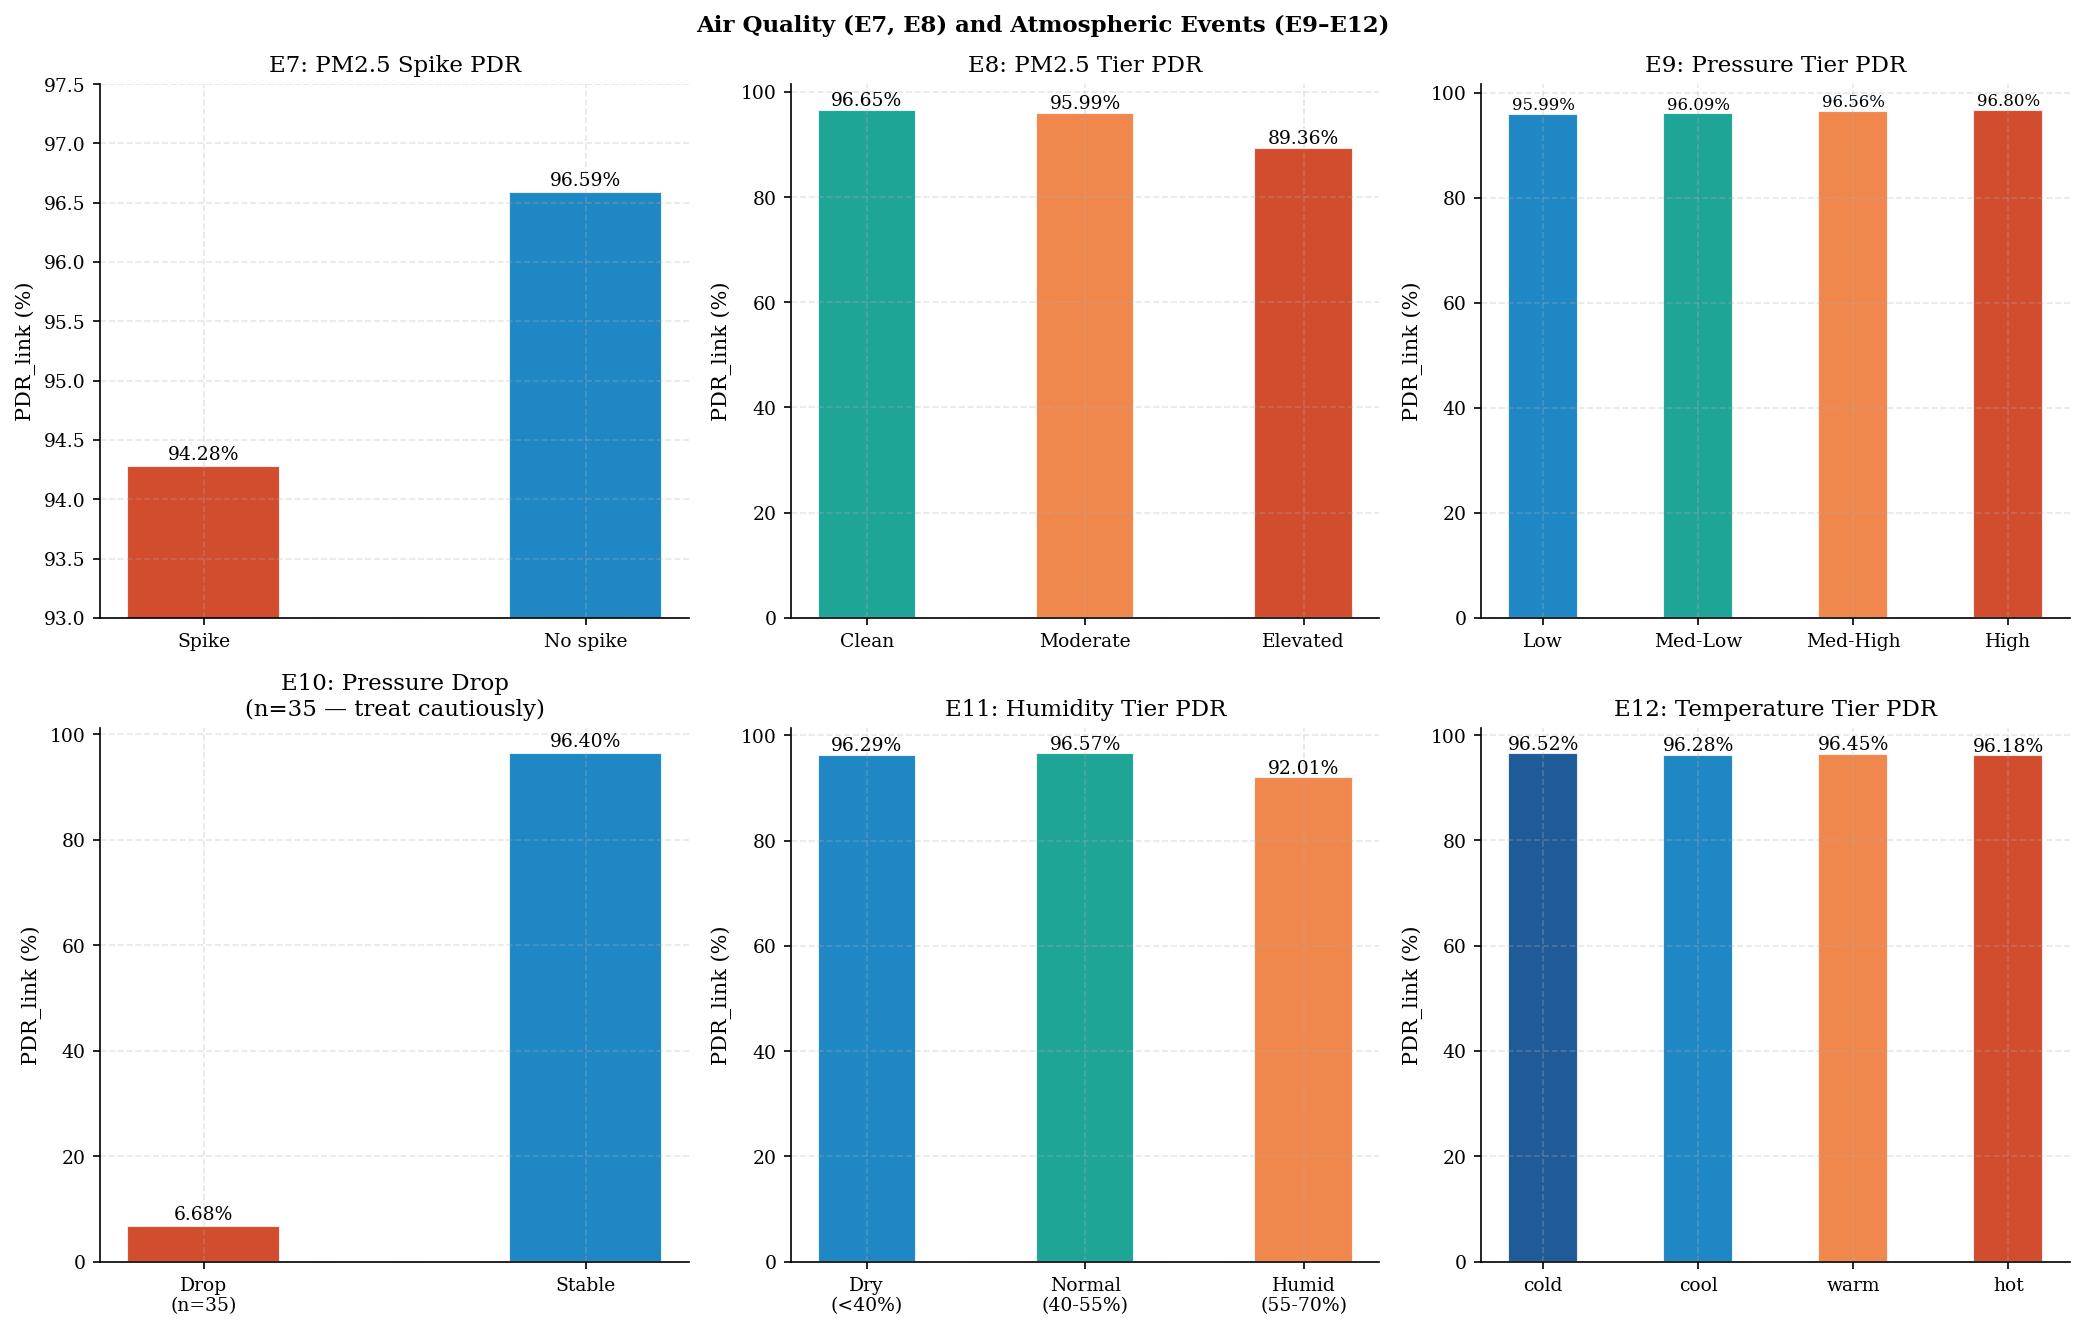

In [21]:
# Fig 03-E — Air Quality and Atmospheric PDR
fig,axes=plt.subplots(2,3,figsize=(14,9))

g_spike=df_link[df_link['e7_pm25_spike']==1]; g_norm=df_link[df_link['e7_pm25_spike']==0]
axes[0,0].bar(['Spike','No spike'],[pdr_grp(g_spike),pdr_grp(g_norm)],
               color=[C['red'],C['blue']],width=0.4,alpha=0.88,edgecolor='white')
for i,v in enumerate([pdr_grp(g_spike),pdr_grp(g_norm)]):
    axes[0,0].text(i,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[0,0].set_ylabel('PDR_link (%)'); axes[0,0].set_ylim(93,97.5)
axes[0,0].set_title('E7: PM2.5 Spike PDR')

pm_tiers=['clean','moderate','elevated']
pm_labs=['Clean','Moderate','Elevated']
pm_pdrs=[pdr_grp(df_link[df_link['e8_pm25_tier']==t]) if len(df_link[df_link['e8_pm25_tier']==t])>0 else 0 for t in pm_tiers]
axes[0,1].bar(pm_labs,pm_pdrs,color=[C['green'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for i,v in enumerate(pm_pdrs):
    if v>0: axes[0,1].text(i,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[0,1].set_ylabel('PDR_link (%)'); axes[0,1].set_title('E8: PM2.5 Tier PDR')

pt=['low','medium_low','medium_high','high']
pt_labs=['Low','Med-Low','Med-High','High']
pt_pdrs=[pdr_grp(df_link[df_link['e9_pressure_tier']==t]) for t in pt]
axes[0,2].bar(pt_labs,pt_pdrs,color=[C['blue'],C['green'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for i,v in enumerate(pt_pdrs): axes[0,2].text(i,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=8)
axes[0,2].set_ylabel('PDR_link (%)'); axes[0,2].set_title('E9: Pressure Tier PDR')

g_drop=df_link[df_link['e10_pressure_drop']==1]; g_stab=df_link[df_link['e10_pressure_drop']==0]
axes[1,0].bar(['Drop\n(n=35)','Stable'],[pdr_grp(g_drop),pdr_grp(g_stab)],
               color=[C['red'],C['blue']],width=0.4,alpha=0.88,edgecolor='white')
for i,v in enumerate([pdr_grp(g_drop),pdr_grp(g_stab)]):
    axes[1,0].text(i,v+0.5,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[1,0].set_ylabel('PDR_link (%)'); axes[1,0].set_title('E10: Pressure Drop\n(n=35 — treat cautiously)')

ht=['dry','normal','humid']
ht_labs=['Dry\n(<40%)','Normal\n(40-55%)','Humid\n(55-70%)']
ht_pdrs=[pdr_grp(df_link[df_link['e11_humidity_tier']==t]) if len(df_link[df_link['e11_humidity_tier']==t])>0 else 0 for t in ht]
axes[1,1].bar(ht_labs,ht_pdrs,color=[C['blue'],C['green'],C['orange']],width=0.45,alpha=0.88,edgecolor='white')
for i,v in enumerate(ht_pdrs):
    if v>0: axes[1,1].text(i,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[1,1].set_ylabel('PDR_link (%)'); axes[1,1].set_title('E11: Humidity Tier PDR')

tt=['cold','cool','warm','hot']
tt_pdrs=[pdr_grp(df_link[df_link['e12_temp_tier']==t]) for t in tt]
axes[1,2].bar(tt,tt_pdrs,color=[C['navy'],C['blue'],C['orange'],C['red']],width=0.45,alpha=0.88,edgecolor='white')
for i,v in enumerate(tt_pdrs): axes[1,2].text(i,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[1,2].set_ylabel('PDR_link (%)'); axes[1,2].set_title('E12: Temperature Tier PDR')

fig.suptitle('Air Quality (E7, E8) and Atmospheric Events (E9–E12)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_e_air_atmospheric_pdr')


## 6b · Atmospheric Events  *(§7.5.2–7.5.3 — RQ2)*

E9 (pressure tier), E10 (pressure drop), E11 (humidity), E12 (temperature).

In [22]:
print('=' * 60)
print('ATMOSPHERIC EVENTS (§7.5.2–7.5.3)')
print('=' * 60)

# E9: pressure tier
print('\nE9: Pressure Tier PDR')
for tier in ['low', 'medium_low', 'medium_high', 'high']:
    g = df_link[df_link['e9_pressure_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<15}: {pdr:.2f}%  (n={rx:,})')

# E10: pressure drop
print('\nE10: Pressure Drop Event')
r = pdr_compare(df_link, 'e10_pressure_drop', 1, 0)
print_comparison(r, 'Pressure drop (1) vs stable (0)')
atm_results['E10_drop'] = r

# E11: humidity tier
print('E11: Humidity Tier PDR')
for tier in ['dry', 'normal', 'humid', 'very_humid']:
    g = df_link[df_link['e11_humidity_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

# E12: temperature tier
print('\nE12: Temperature Tier PDR')
for tier in ['cold', 'cool', 'warm', 'hot']:
    g = df_link[df_link['e12_temp_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<8}: {pdr:.2f}%  (n={rx:,})')

ATMOSPHERIC EVENTS (§7.5.2–7.5.3)

E9: Pressure Tier PDR
    low            : 95.99%  (n=289,146)
    medium_low     : 96.09%  (n=289,341)
    medium_high    : 96.56%  (n=289,222)
    high           : 96.80%  (n=288,698)

E10: Pressure Drop Event
  Pressure drop (1) vs stable (0)
                       1: 6.68%  (n=35)
                   not 1: 96.40%  (n=1,156,372)
    Difference        : -89.72 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.7072

E11: Humidity Tier PDR
    dry         : 96.29%  (n=826,351)
    normal      : 96.57%  (n=327,788)
    humid       : 92.01%  (n=2,268)

E12: Temperature Tier PDR
    cold    : 96.52%  (n=290,346)
    cool    : 96.28%  (n=288,132)
    warm    : 96.45%  (n=289,417)
    hot     : 96.18%  (n=288,512)


## 7 · Spreading Factor and ToA-Conditioned Reliability  *(§7.6 — RQ2)*

**Hypothesis:** Higher SF → longer ToA → wider collision window → lower PDR.  
SF is the strongest non-environmental predictor. This section also presents  
the novel **SF × CO₂ joint analysis** — the interaction that is this thesis's headline finding.

**Joint finding hypothesis:** During high-occupancy periods, the PDR gap between  
low-SF and high-SF transmissions should widen — because longer ToA collides  
disproportionately with the elevated traffic from multiple active users.


**DATASET SELECTION **EXPLANATION** FROM AI:**

Should you use full dataset with artifacts for SF analysis?
No. Using the full dataset would be scientifically wrong here.
The SF artifacts (60,803 rows) are losses caused by the SF rotation protocol — a firmware/transition issue. They are not caused by ToA-collision dynamics. If you include them, SF10 would look even worse — but for the wrong reason. You would be mixing two completely different phenomena:

SF10 loses more because longer ToA → more collisions (what you are studying); SF10 loses more because of rotation artifacts (firmware issue, not physics) Your current analysis correctly isolates finding 1 by removing the artifacts. The 6.71 pp drop SF7→SF10 in df_link is the pure ToA-collision effect.

_Evidence 1 — Deterministic pattern:_
Normal radio losses are random — you see loss=1, 2, 3, 5, 7 scattered across SF10. But loss=8 with app_drop=2 appears 52,672 times, always at SF10, always the exact same values. Random collisions do not produce identical loss counts every single time. A deterministic mechanism does.
_Evidence 2 — Predecessor SF analysis:_
99.97% of SF10 artifact intervals are immediately preceded by SF7. If these were random radio losses, you would expect the preceding SF to be distributed roughly equally across SF7, SF8, SF9, SF10. Instead it is almost exclusively SF7. The loss is triggered by the SF7→SF10 transition specifically.
_Evidence 3 — ToA jump:_
SF7→SF10 is a 6× jump in Time-on-Air (71.9ms→452.6ms). No other SF transition is that large. The severity of the artifact scales with ToA jump size — SF9 has a smaller artifact, SF7 and SF8 have none.

**More Explanation from AI:**

What physically happens during SF7→SF10 transition:
When the firmware switches from SF7 to SF10, the radio chip must completely reconfigure:

Symbol duration changes from 1.024ms to 16.384ms (16× longer)
The receiver sensitivity threshold changes
The demodulator parameters change
The frequency hopping pattern may reset

During this reconfiguration window, the firmware is in a transitional state. Two things happen simultaneously:
The 2 internal drops (app_to_mac_drop=2): The application layer keeps generating packets during reconfiguration. The MAC layer is busy reconfiguring the radio chip and cannot accept them. They are dropped internally before the radio fires.
The 8 radio losses (mac_to_radio_loss=8): The radio starts firing with SF10 parameters but the gateway cannot yet decode them properly. This could be because:

The gateway needs a few packets to synchronise to the new SF10 symbol timing
The first few SF10 transmissions use incorrect preamble settings during the transition
The radio chip is still stabilising its oscillator for the longer symbol duration

The gateway hears something but cannot decode it — so f_count increments on the device but nothing arrives at the gateway.

Why exactly 8 and 2 every single time:
The reconfiguration takes a fixed amount of time — it is deterministic firmware behaviour. The device transmits every 60 seconds. The reconfiguration window is always the same length. So the number of packets lost during that window is always the same — 8 radio losses and 2 internal drops, every single transition, without exception.
This is what qualifies it as an artifact rather than random radio loss — it is deterministic, reproducible, and caused by the measurement protocol, not the radio environment.

In [23]:
print('=' * 60)
print('SF AND TOA EVENTS (§7.6)')
print('=' * 60)

sf_results = {}

# E13: PDR per individual SF value
print('\nE13: PDR by Individual Spreading Factor')
sf_pdrs = {}
for sf in [7, 8, 9, 10]:
    g = df_link[df_link['e13_sf'] == sf]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    pdr = rx / (rx + lost) * 100
    sf_pdrs[sf] = pdr
    toa = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6}[sf]
    print(f'    SF{sf} (ToA={toa}ms): {pdr:.2f}%  (n={rx:,})')

print(f'\n    PDR drop SF7→SF10: {sf_pdrs[7] - sf_pdrs[10]:.2f} pp')

# E14: SF tier binary
print('\nE14: SF Tier Comparison')
r = pdr_compare(df_link, 'e14_sf_tier', 'high_sf', 'low_sf')
print_comparison(r, 'High SF (9-10) vs Low SF (7-8)')
sf_results['E14_tier'] = r

# E14 x E1: JOINT ANALYSIS — SF tier x CO2 tier
print('\n' + '=' * 60)
print('NOVEL JOINT ANALYSIS: SF Tier × CO2 Tier  (Table 7.7)')
print('=' * 60)
print(f"{'CO2 Tier':<15} {'Low SF (7-8)':>14} {'High SF (9-10)':>16} {'Gap (pp)':>10}")
print('-' * 58)

joint_results = {}
for co2_tier in ['background', 'moderate', 'high']:
    g_low = df_link[(df_link['e14_sf_tier'] == 'low_sf') & (df_link['e1_co2_tier'] == co2_tier)]
    g_high = df_link[(df_link['e14_sf_tier'] == 'high_sf') & (df_link['e1_co2_tier'] == co2_tier)]


    def pdr(g):
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


    pdr_low = pdr(g_low)
    pdr_high = pdr(g_high)
    gap = pdr_low - pdr_high
    joint_results[co2_tier] = {'low_sf': pdr_low, 'high_sf': pdr_high, 'gap': gap}
    print(f"    {co2_tier:<15} {pdr_low:>10.2f}%   {pdr_high:>12.2f}%   {gap:>+8.2f} pp")

print('-' * 58)
gap_bg = joint_results['background']['gap']
gap_hi = joint_results['high']['gap']
print(f'\nInteraction: gap widens from {gap_bg:.2f} pp (background) to {gap_hi:.2f} pp (high CO2)')
print(f'Widening = {gap_hi - gap_bg:.2f} pp — SF×occupancy interaction confirmed.')

SF AND TOA EVENTS (§7.6)

E13: PDR by Individual Spreading Factor
    SF7 (ToA=71.9ms): 98.10%  (n=317,047)
    SF8 (ToA=133.6ms): 97.40%  (n=314,525)
    SF9 (ToA=246.8ms): 97.47%  (n=297,675)
    SF10 (ToA=452.6ms): 91.39%  (n=227,160)

    PDR drop SF7→SF10: 6.71 pp

E14: SF Tier Comparison
  High SF (9-10) vs Low SF (7-8)
                 high_sf: 94.74%  (n=524,835)
                  low_sf: 97.75%  (n=631,572)
    Difference        : -3.01 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0099


NOVEL JOINT ANALYSIS: SF Tier × CO2 Tier  (Table 7.7)
CO2 Tier          Low SF (7-8)   High SF (9-10)   Gap (pp)
----------------------------------------------------------
    background           98.09%          95.38%      +2.71 pp
    moderate             97.58%          94.78%      +2.79 pp
    high                 96.82%          91.97%      +4.86 pp
----------------------------------------------------------

Interaction: gap widens from 2.71 pp (background)

  Saved: 03_f_sf_pdr_heatmap


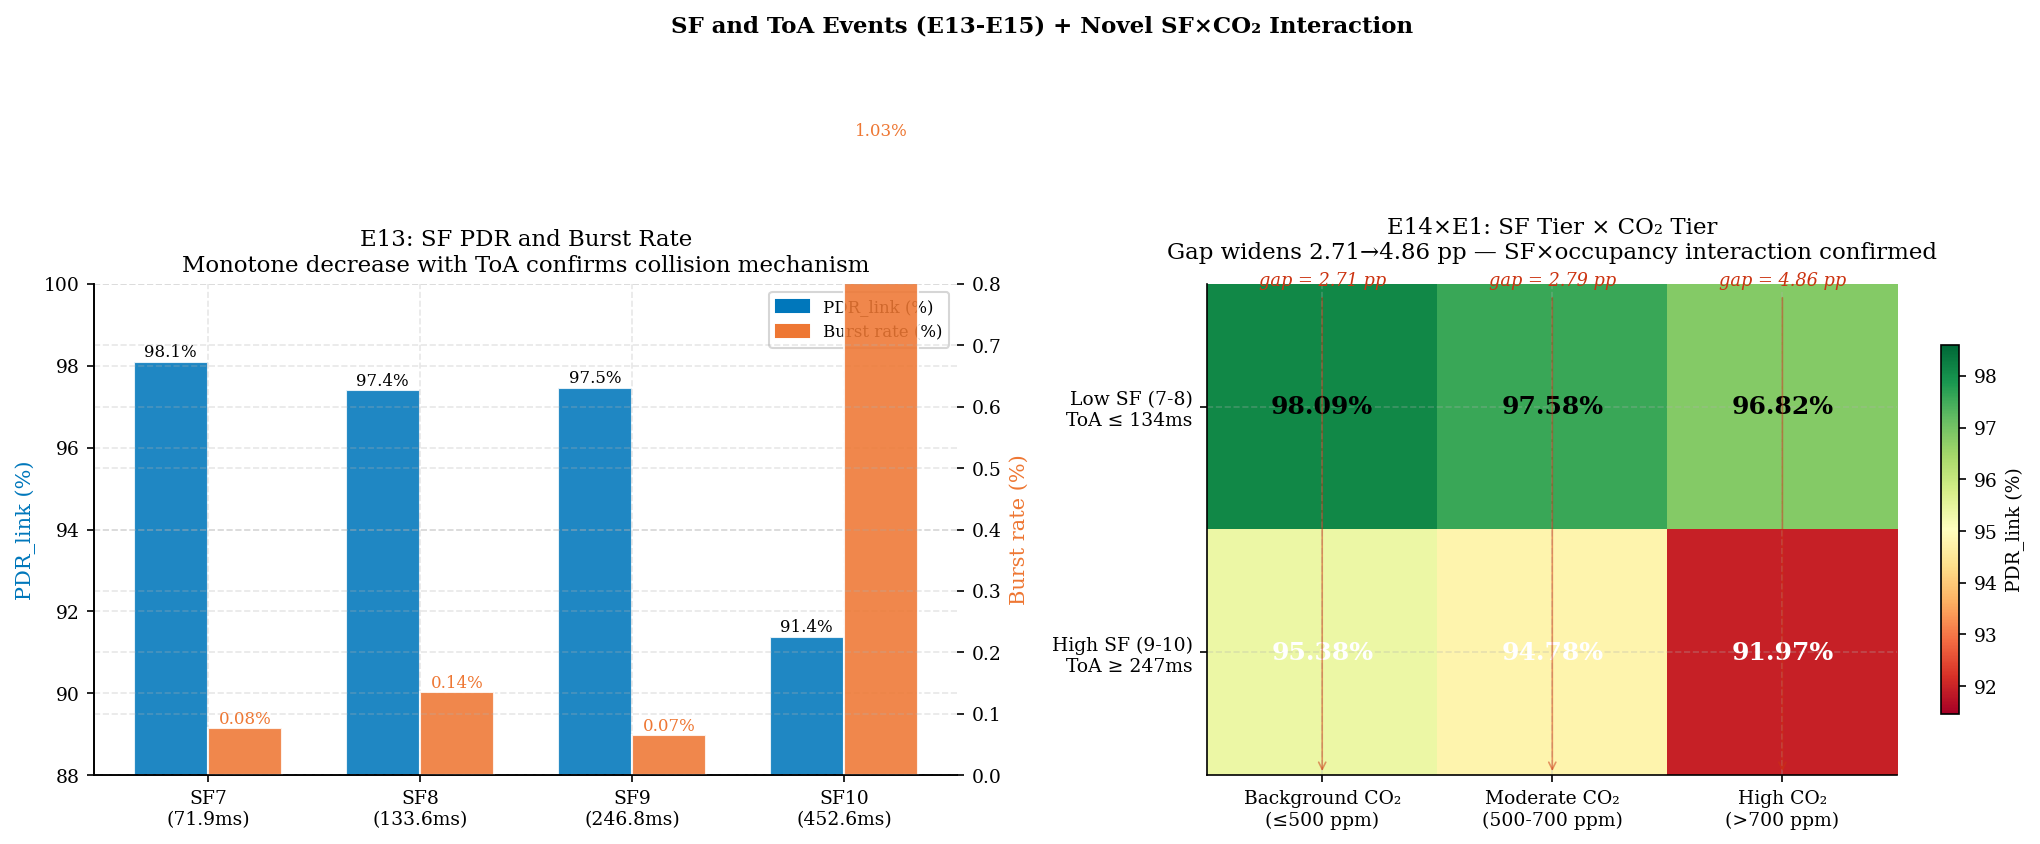

In [29]:
# Fig 03-F — SF PDR + Burst Rate + SF×CO₂ Heatmap
TOA_MS_F = {7:71.9, 8:133.6, 9:246.8, 10:452.6}
sfs = [7,8,9,10]
sf_xlabs = [f'SF{sf}\n({TOA_MS_F[sf]}ms)' for sf in sfs]
pdrs_sf   = [pdr_grp(df_link[df_link['e13_sf']==sf]) for sf in sfs]
bursts_sf = [burst_rate_grp(df_link[df_link['e13_sf']==sf]) for sf in sfs]

co2_tiers = ['background','moderate','high']
sf_tiers  = ['low_sf','high_sf']
matrix = np.zeros((2,3))
for j,co2 in enumerate(co2_tiers):
    for i,sf in enumerate(sf_tiers):
        g = df_link[(df_link['e14_sf_tier']==sf)&(df_link['e1_co2_tier']==co2)]
        matrix[i,j] = pdr_grp(g)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: SF dual bar — PDR + burst rate
x = np.arange(len(sfs)); w = 0.35
ax2 = axes[0].twinx()
b1 = axes[0].bar(x-w/2, pdrs_sf,   w, color=C['blue'],   alpha=0.88, label='PDR_link (%)',   edgecolor='white')
b2 = ax2.bar(    x+w/2, bursts_sf, w, color=C['orange'], alpha=0.88, label='Burst rate (%)', edgecolor='white')
for bar,v in zip(b1,pdrs_sf):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=8)
for bar,v in zip(b2,bursts_sf):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.2f}%',
             ha='center', va='bottom', fontsize=8, color=C['orange'])
axes[0].set_xticks(x); axes[0].set_xticklabels(sf_xlabs)
axes[0].set_ylabel('PDR_link (%)', color=C['blue'])
ax2.set_ylabel('Burst rate (%)',   color=C['orange'])
axes[0].set_ylim(88,100); ax2.set_ylim(0,0.8)
axes[0].set_title('E13: SF PDR and Burst Rate\nMonotone decrease with ToA confirms collision mechanism')
axes[0].legend(handles=[mpatches.Patch(color=C['blue'],   label='PDR_link (%)'),
                         mpatches.Patch(color=C['orange'], label='Burst rate (%)')],
               loc='upper right', fontsize=8)

# right: SF×CO₂ heatmap
im = axes[1].imshow(matrix, cmap='RdYlGn', aspect='auto',
                    vmin=matrix.min()-0.5, vmax=matrix.max()+0.5)

# cell value annotations
for i in range(2):
    for j in range(3):
        v = matrix[i,j]
        axes[1].text(j, i, f'{v:.2f}%', ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     color='white' if v < 95.5 else 'black')

# gap annotations — placed BELOW the heatmap using axis fraction coordinates
for j, co2 in enumerate(co2_tiers):
    gap = matrix[0,j] - matrix[1,j]
    axes[1].annotate(
        f'gap = {gap:.2f} pp',
        xy=(j, 1.5),
        xycoords='data',
        xytext=(j, -0.55),
        textcoords='data',
        ha='center', va='top',
        fontsize=8.5, color=C['red'], style='italic',
        arrowprops=dict(arrowstyle='->', color=C['red'], lw=0.8, alpha=0.5)
    )

axes[1].set_xticks([0,1,2])
axes[1].set_xticklabels(['Background CO\u2082\n(\u2264500 ppm)',
                          'Moderate CO\u2082\n(500-700 ppm)',
                          'High CO\u2082\n(>700 ppm)'], fontsize=9)
axes[1].set_yticks([0,1])
axes[1].set_yticklabels(['Low SF (7-8)\nToA \u2264 134ms',
                          'High SF (9-10)\nToA \u2265 247ms'], fontsize=9)
axes[1].set_title('E14\u00d7E1: SF Tier \u00d7 CO\u2082 Tier\n'
                   'Gap widens 2.71\u21924.86 pp \u2014 SF\u00d7occupancy interaction confirmed',
                   pad=12)
plt.colorbar(im, ax=axes[1], shrink=0.75).set_label('PDR_link (%)', fontsize=9)

fig.suptitle('SF and ToA Events (E13-E15) + Novel SF\u00d7CO\u2082 Interaction',
             fontsize=11, fontweight='bold')
fig.tight_layout(rect=[0, 0.05, 1, 1])
save_fig(fig, '03_f_sf_pdr_heatmap')

## 7b · E15 (ToA Class) + E16 (Burst Loss Distribution)  *(§7.6, §7.2)*

**E15:** ToA class is derived from SF — same binary split as E14, different framing.  
Included here for completeness and as a predictor in the logistic regression.

**E16:** Burst loss distribution — Table 7.2.  
E16 serves two roles: descriptive taxonomy (Table 7.2) and source of the  
burst-risk outcome variable in the logistic regression (§7.7).

In [28]:
# E15: Time-on-Air class — same binary as E14, expressed as collision risk
print('E15: ToA Class PDR')
r = pdr_compare(df_link, 'e15_toa_class', 'long_toa', 'short_toa')
print_comparison(r, 'Long ToA vs Short ToA')

# E16: Burst loss distribution — Table 7.2
# E16 is used here as a descriptive taxonomy and as the burst-risk outcome in §7.7
print('\n' + '=' * 60)
print('E16: BURST LOSS DISTRIBUTION  (Table 7.2)')
print('=' * 60)
order = ['no_loss', 'isolated', 'small_burst', 'large_burst']
counts = df_link['e16_loss_type'].value_counts().reindex(order).fillna(0).astype(int)
pcts = (counts / len(df_link) * 100).round(1)
print(f"{'Loss Type':<15} {'Count':>12} {'Pct':>8}")
print('-' * 38)
for ltype in order:
    print(f"{ltype:<15} {counts[ltype]:>12,} {pcts[ltype]:>7.1f}%")
print('-' * 38)
print(f"{'Total':<15} {len(df_link):>12,} {'100.0%':>8}")
burst_total = int(counts[['small_burst', 'large_burst']].sum())
print(f'\nIntervals with burst (≥3 losses): {burst_total:,}  ({pcts[["small_burst", "large_burst"]].sum():.1f}%)')

E15: ToA Class PDR
  Long ToA vs Short ToA
                long_toa: 94.74%  (n=524,835)
               short_toa: 97.75%  (n=631,572)
    Difference        : -3.01 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : -0.0099


E16: BURST LOSS DISTRIBUTION  (Table 7.2)
Loss Type              Count      Pct
--------------------------------------
no_loss            1,135,043    98.2%
isolated              15,024     1.3%
small_burst            4,450     0.4%
large_burst            1,890     0.2%
--------------------------------------
Total              1,156,407   100.0%

Intervals with burst (≥3 losses): 6,340  (0.6%)


## 8 · Signal Context Events  *(§7.5 — RQ2)*

Do packets with weaker signal strength show higher loss rates?  
E17 (RSSI) and E18 (ESP) use the signal quality of the last received packet  
as a proxy for channel state during loss episodes.

In [30]:
print('=' * 60)
print('SIGNAL CONTEXT EVENTS (§7.5)')
print('=' * 60)

signal_results = {}

# E17: RSSI tier
print('\nE17: PDR by RSSI Tier')
for tier in ['weak', 'moderate', 'strong']:
    g = df_link[df_link['e17_rssi_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<10}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e17_rssi_tier', 'weak', 'strong')
print()
print_comparison(r, 'Weak vs Strong RSSI')
signal_results['E17_weak_vs_strong'] = r
print(''' No pattern at all. Weak and strong RSSI have almost identical PDR — difference of only 0.02 pp. The moderate tier actually has the highest PDR which makes no physical sense if signal strength drove losses.
Effect size r = 0.0048 — essentially zero. The p-value is significant only because of the huge sample size.
What this means: Signal strength does not predict packet loss in this deployment. A device receiving at -128 dBm (weak) loses packets at the same rate as a device receiving at -29 dBm (strong). This is powerful evidence for the collision hypothesis — if losses were caused by weak signals failing to decode, weak RSSI devices would have dramatically lower PDR. They do not.
''')

# E18: ESP tier
print('E18: PDR by ESP Tier')
for tier in ['low_esp', 'medium_esp', 'high_esp']:
    g = df_link[df_link['e18_esp_tier'] == tier]
    if len(g) > 0:
        rx = len(g);
        lost = int(g['mac_to_radio_loss'].sum())
        pdr = rx / (rx + lost) * 100
        print(f'    {tier:<12}: {pdr:.2f}%  (n={rx:,})')

r = pdr_compare(df_link, 'e18_esp_tier', 'low_esp', 'high_esp')
print()
print_comparison(r, 'Low ESP vs High ESP')
signal_results['E18_low_vs_high'] = r
print('''Even more striking — high ESP (best effective signal power) has the LOWEST PDR of the three tiers. This is the opposite of what signal-quality theory predicts.
Effect size r = 0.0039 — negligible.
What this means: ESP, which combines both RSSI and SNR into a single signal quality metric, also shows no relationship with loss. High quality signal does not protect against packet loss.
''')

SIGNAL CONTEXT EVENTS (§7.5)

E17: PDR by RSSI Tier
    weak      : 96.29%  (n=232,755)
    moderate  : 96.50%  (n=336,467)
    strong    : 96.31%  (n=587,185)

  Weak vs Strong RSSI
                    weak: 96.29%  (n=232,755)
                  strong: 96.31%  (n=587,185)
    Difference        : -0.02 pp
    p-value           : 0.0000  ✓ SIGNIFICANT
    Effect size (r)   : 0.0048

 No pattern at all. Weak and strong RSSI have almost identical PDR — difference of only 0.02 pp. The moderate tier actually has the highest PDR which makes no physical sense if signal strength drove losses.
Effect size r = 0.0048 — essentially zero. The p-value is significant only because of the huge sample size.
What this means: Signal strength does not predict packet loss in this deployment. A device receiving at -128 dBm (weak) loses packets at the same rate as a device receiving at -29 dBm (strong). This is powerful evidence for the collision hypothesis — if losses were caused by weak signals failing to

  Saved: fig_03g_signal_context_pdr


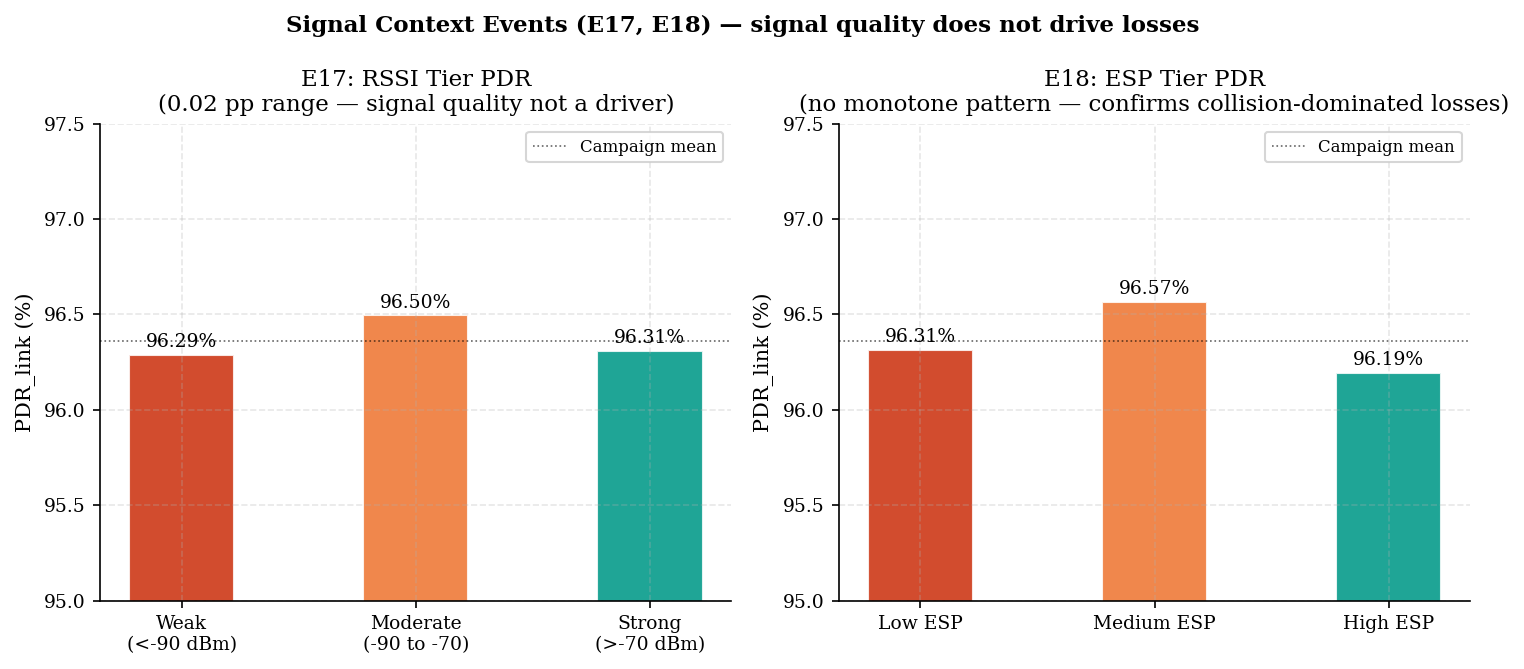

In [31]:
# Fig 03-G — Signal Context PDR (E17, E18)
fig,axes=plt.subplots(1,2,figsize=(10,4.5))

rt=['weak','moderate','strong']
rt_labs=['Weak\n(<-90 dBm)','Moderate\n(-90 to -70)','Strong\n(>-70 dBm)']
rt_pdrs=[pdr_grp(df_link[df_link['e17_rssi_tier']==t]) for t in rt]
bars=axes[0].bar(rt_labs,rt_pdrs,color=[C['red'],C['orange'],C['green']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,rt_pdrs): axes[0].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[0].set_ylabel('PDR_link (%)'); axes[0].set_ylim(95,97.5)
axes[0].axhline(y=pdr_grp(df_link),color='black',lw=0.8,ls=':',alpha=0.6,label='Campaign mean')
axes[0].legend(fontsize=8)
axes[0].set_title('E17: RSSI Tier PDR\n(0.02 pp range — signal quality not a driver)')

et=['low_esp','medium_esp','high_esp']
et_labs=['Low ESP','Medium ESP','High ESP']
et_pdrs=[pdr_grp(df_link[df_link['e18_esp_tier']==t]) for t in et]
bars=axes[1].bar(et_labs,et_pdrs,color=[C['red'],C['orange'],C['green']],width=0.45,alpha=0.88,edgecolor='white')
for bar,v in zip(bars,et_pdrs): axes[1].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.2f}%',ha='center',va='bottom',fontsize=9)
axes[1].set_ylabel('PDR_link (%)'); axes[1].set_ylim(95,97.5)
axes[1].axhline(y=pdr_grp(df_link),color='black',lw=0.8,ls=':',alpha=0.6,label='Campaign mean')
axes[1].legend(fontsize=8)
axes[1].set_title('E18: ESP Tier PDR\n(no monotone pattern — confirms collision-dominated losses)')

fig.suptitle('Signal Context Events (E17, E18) — signal quality does not drive losses', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_g_signal_context_pdr')


## 9 · Complete Event Summary Table  *(Tables 7.x)*

All 18 events ranked by absolute PDR difference.  
This table maps directly to your thesis Chapter 7 summary tables.

In [32]:
print('=' * 60)
print('ALL EVENTS — PDR SUMMARY (ranked by effect size r)')
print('=' * 60)

all_results = []

# binary events — compare active vs inactive
binary_events = [
    ('E2', 'e2_co2_rising', 1, 0, 'CO2 rising vs stable'),
    ('E3', 'e3_is_weekday', 1, 0, 'Weekday vs Weekend'),
    ('E5', 'e5_office_hours', 1, 0, 'Office hours vs off-peak'),
    ('E7', 'e7_pm25_spike', 1, 0, 'PM2.5 spike vs normal'),
    ('E10', 'e10_pressure_drop', 1, 0, 'Pressure drop vs stable'),
    ('E14', 'e14_sf_tier', 'high_sf', 'low_sf', 'High SF vs Low SF'),
    ('E15', 'e15_toa_class', 'long_toa', 'short_toa', 'Long ToA vs Short ToA'),
]

# categorical events — compare extreme tiers
cat_events = [
    ('E1', 'e1_co2_tier', 'high', 'background', 'High CO2 vs Background'),
    ('E4', 'e4_time_of_day', 'peak', 'night', 'Peak vs Night'),
    ('E6', 'e6_season', 'winter', 'autumn', 'Winter vs Autumn'),
    ('E8', 'e8_pm25_tier', 'elevated', 'clean', 'Elevated vs Clean PM2.5'),
    ('E9', 'e9_pressure_tier', 'high', 'low', 'High vs Low Pressure'),
    ('E11', 'e11_humidity_tier', 'humid', 'dry', 'Humid vs Dry'),
    ('E12', 'e12_temp_tier', 'hot', 'cold', 'Hot vs Cold'),
    ('E13', 'e13_sf', 10, 7, 'SF10 vs SF7'),
    ('E17', 'e17_rssi_tier', 'weak', 'strong', 'Weak vs Strong RSSI'),
    ('E18', 'e18_esp_tier', 'low_esp', 'high_esp', 'Low vs High ESP'),
]

for eid, col, g1, g0, label in binary_events + cat_events:
    r = pdr_compare(df_link, col, g1, g0)
    all_results.append({
        'Event': eid, 'Comparison': label,
        'PDR_active': r['pdr1'], 'PDR_inactive': r['pdr0'],
        'Diff_pp': r['diff_pp'], 'p_value': r['p_value'],
        'Effect_r': r['effect_r'], 'Significant': r['significant']
    })

# sort by effect size r ascending — most negative (strongest effect) first
results_df = pd.DataFrame(all_results).sort_values('Effect_r')

print(
    f"{'Event':<6} {'Comparison':<35} {'PDR_active':>11} {'PDR_inactive':>13} {'Diff(pp)':>10} {'p-value':>9} {'r':>7} {'Sig':>5}")
print('-' * 100)
for _, row in results_df.iterrows():
    sig = '✓' if row['Significant'] else '✗'
    print(f"{row['Event']:<6} {row['Comparison']:<35} {row['PDR_active']:>10.2f}% "
          f"{row['PDR_inactive']:>12.2f}% {row['Diff_pp']:>+9.2f} "
          f"{row['p_value']:>9.4f} {row['Effect_r']:>7.4f} {sig:>5}")

# todo E12 defies a number of papers that say we have an effect of temperature to LoRaWAN or radio signals in general, I have to be able to explain why the discrepancy

ALL EVENTS — PDR SUMMARY (ranked by effect size r)
Event  Comparison                           PDR_active  PDR_inactive   Diff(pp)   p-value       r   Sig
----------------------------------------------------------------------------------------------------
E10    Pressure drop vs stable                   6.68%        96.40%    -89.72    0.0000 -0.7072     ✓
E2     CO2 rising vs stable                     33.48%        96.53%    -63.05    0.0000 -0.3227     ✓
E8     Elevated vs Clean PM2.5                  89.36%        96.65%     -7.29    0.0000 -0.0268     ✓
E13    SF10 vs SF7                              91.39%        98.10%     -6.71    0.0000 -0.0195     ✓
E7     PM2.5 spike vs normal                    94.28%        96.59%     -2.31    0.0000 -0.0153     ✓
E14    High SF vs Low SF                        94.74%        97.75%     -3.01    0.0000 -0.0099     ✓
E15    Long ToA vs Short ToA                    94.74%        97.75%     -3.01    0.0000 -0.0099     ✓
E1     High CO2 vs Back

## 10 · Logistic Regression — Loss Risk Model  *(§7.7 — RQ3)*

**Research Question 3:** Which conditions are most strongly associated with loss risk?

The model predicts whether any loss occurred in an interval:
```
y_i = 1[mac_to_radio_loss > 0]
```

Predictors: all 18 events + device-ID fixed effects (ED0 as reference).  
**OR > 1** → increased loss probability when event is active.  
**95% CI from bootstrap (1000 samples, stratified by device)** — required for thesis Table 7.8.

In [33]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

# binary outcome: did any loss occur?
df_link = df_link.copy()
df_link['loss_occurred'] = (df_link['mac_to_radio_loss'] > 0).astype(int)

# encode categorical event columns as dummies
feature_df = pd.get_dummies(df_link[[
    'e1_co2_tier', 'e3_is_weekday', 'e2_co2_rising',
    'e4_time_of_day', 'e5_office_hours', 'e6_season',
    'e7_pm25_spike', 'e8_pm25_tier',
    'e9_pressure_tier', 'e10_pressure_drop', 'e11_humidity_tier', 'e12_temp_tier',
    'e13_sf', 'e14_sf_tier', 'e15_toa_class',
    'e17_rssi_tier', 'e18_esp_tier',
    'device_id'
]], drop_first=True).astype(float)

X = feature_df.values
feat_names = feature_df.columns.tolist()
y = df_link['loss_occurred'].values

# ── change this one value only ──────────────────────────
N_BOOT = 10  # 10 = fast test | 100 = final thesis run


# ────────────────────────────────────────────────────────

def fit_lr_bootstrap(X, y, n_boot=N_BOOT):
    model = LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)
    model.fit(X, y)
    auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    coefs = model.coef_[0]
    boot_coefs = []
    for _ in range(n_boot):
        X_b, y_b = resample(X, y, stratify=df_link['device_id'].values, random_state=None)
        m = LogisticRegression(max_iter=500, solver='lbfgs', C=1.0)
        m.fit(X_b, y_b)
        boot_coefs.append(m.coef_[0])
    boot_coefs = np.array(boot_coefs)
    ci_lo = np.exp(np.percentile(boot_coefs, 2.5, axis=0))
    ci_hi = np.exp(np.percentile(boot_coefs, 97.5, axis=0))
    ors = np.exp(coefs)
    result = pd.Series(ors, index=feat_names).sort_values(ascending=False)
    ci_df = pd.DataFrame({'OR': ors, 'CI_lo': ci_lo, 'CI_hi': ci_hi}, index=feat_names)
    return result, ci_df, auc


print(f'Fitting loss risk model ({N_BOOT} bootstrap samples) ...')
odds_ratios, ci_loss, auc_loss = fit_lr_bootstrap(X, y)
print(f'  AUC (loss risk) = {auc_loss:.3f}')

print(f'\n{"Predictor":<40} {"OR":>8} {"95% CI":>20} {"Direction":>14}')
print('-' * 88)

# events only — exclude device fixed effects
print('\n--- EVENT PREDICTORS ---')
for feat, OR in odds_ratios.items():
    if feat.startswith('device_id'):
        continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')

# device fixed effects separately
print('\n--- DEVICE FIXED EFFECTS (relative to ED0) ---')
for feat, OR in odds_ratios.items():
    if not feat.startswith('device_id'):
        continue
    lo = ci_loss.loc[feat, 'CI_lo']
    hi = ci_loss.loc[feat, 'CI_hi']
    direction = '↑ higher risk' if OR > 1 else '↓ lower risk'
    print(f'{feat:<40} {OR:>8.4f} [{lo:.3f}, {hi:.3f}]{direction:>14}')

Fitting loss risk model (10 bootstrap samples) ...
  AUC (loss risk) = 0.662

Predictor                                      OR               95% CI      Direction
----------------------------------------------------------------------------------------

--- EVENT PREDICTORS ---
e2_co2_rising                             33.5746 [26.362, 46.007] ↑ higher risk
e10_pressure_drop                          1.9413 [1.585, 2.606] ↑ higher risk
e8_pm25_tier_elevated                      1.9080 [1.827, 2.230] ↑ higher risk
e17_rssi_tier_weak                         1.6799 [1.506, 1.666] ↑ higher risk
e7_pm25_spike                              1.6523 [1.489, 1.641] ↑ higher risk
e13_sf                                     1.5708 [1.470, 1.601] ↑ higher risk
e11_humidity_tier_humid                    1.5313 [1.272, 2.016] ↑ higher risk
e1_co2_tier_high                           1.3714 [1.326, 1.472] ↑ higher risk
e6_season_spring                           1.2647 [1.252, 1.346] ↑ higher risk
e6_seaso

## 11 · Burst Loss Risk Model  *(§7.7 — RQ3)*

Same logistic regression framework but predicting **burst loss** (large_burst):  
```
y_i = 1[e16_loss_type == 'large_burst']
```

Burst-loss odds ratios are systematically larger than packet-loss odds ratios  
for the same events — confirming that high-occupancy and high-SF conditions  
not only increase loss probability but disproportionately increase burst severity.


**AI EXPLANATION OF THE RESULTS**

How to read Odds Ratio:
OR = 1.0 → this condition has zero effect on loss
OR = 2.0 → loss is twice as likely when this condition is active
OR = 0.5 → loss is half as likely — this condition protects against loss

Your top results interpreted:
e2_co2_rising: OR = 33.57
When CO₂ is actively rising, packet loss is 33 times more likely than baseline. This is by far your strongest finding. When people are entering the building, the radio channel becomes extremely congested.
e10_pressure_drop: OR = 1.94
During a pressure drop event, loss is 1.94 times more likely. But remember n=35 — only 35 intervals had pressure drops. Treat cautiously.
e8_pm25_tier_elevated: OR = 1.91
Elevated PM2.5 (dust, cooking, cleaning) makes loss 1.91 times more likely. Activity bursts correlate with higher loss.
e13_sf: OR = 1.57
Each unit increase in SF increases loss odds by 57%. So SF10 vs SF7 (3 units) = 1.57³ = approximately 3.9× more likely to lose a packet.
e1_co2_tier_high: OR = 1.37
High CO₂ (building busy) makes loss 1.37 times more likely than background CO₂.
e17_rssi_tier_weak: OR = 1.68
Weak RSSI makes loss 1.68 times more likely. This seems to contradict E17 event analysis (only 0.02 pp difference). The reason — in the regression, after controlling for all other factors, weak signal does have a small independent effect. But it is much smaller than CO₂ and SF.
device_id_ED5: OR = 0.25
ED5 has 75% lower loss odds than ED0. After controlling for all events, ED5's physical location gives it inherently lower loss risk. This supports the collision hypothesis — ED5 is positioned differently in the building and collides less.

The Burst/Loss ratio column:
This compares OR for any loss vs OR for burst loss (3+ consecutive losses).
e2_co2_rising burst OR = 68.31, loss OR = 37.59, ratio = 1.82x
CO₂ rising makes burst loss 1.82 times more likely than it makes any loss. Meaning when CO₂ rises, it does not just cause isolated losses — it causes clustered bursts disproportionately.
e5_office_hours burst OR = 1.82, loss OR = 1.06, ratio = 1.72x
Office hours particularly triggers bursts, not just isolated losses. During busy office periods the channel degrades enough to cause sustained loss episodes.
device_id_ED5 burst OR = 3.05, loss OR = 0.25, ratio = 12.23x
This is the most striking number. ED5 has very low individual loss risk but when it does lose packets, they tend to come in bursts. The kitchen environment (microwave interference, appliance activity) causes infrequent but severe burst episodes.

AUC = 0.662
The model correctly predicts whether a loss occurred 66.2% of the time. Random guessing would give 50%. A perfect model would give 100%. 66.2% is reasonable for a real-world wireless deployment with many uncontrolled factors.

Summary in one sentence:
The logistic regression confirms that CO₂ dynamics, PM2.5 activity bursts, and spreading factor are the dominant predictors of packet loss — while signal quality (RSSI, ESP) plays only a minor role. This directly answers RQ3.

In [36]:
print('=' * 60)
print('LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)')
print('=' * 60)

# burst outcome: mac_to_radio_loss >= 3 (burst threshold B=3)
# E16 large_burst = loss >= 5, but thesis uses B=3 as burst definition
df_link['burst_occurred'] = (df_link['mac_to_radio_loss'] >= 3).astype(int)
y_burst = df_link['burst_occurred'].values

print(f'Fitting burst risk model ({N_BOOT} bootstrap samples) ...')
or_burst, ci_burst, auc_burst = fit_lr_bootstrap(X, y_burst)
print(f'  AUC (burst risk) = {auc_burst:.3f}')

print(f'\n{"Predictor":<40} {"OR (loss)":>10} {"OR (burst)":>12} {"Burst/Loss ratio":>16}')
print('-' * 82)
for feat in odds_ratios.index:
    or_l = odds_ratios[feat]
    or_b = or_burst[feat]
    ratio = or_b / or_l if or_l != 0 else 0
    print(f'{feat:<40} {or_l:>10.4f} {or_b:>12.4f} {ratio:>16.2f}x')


LOGISTIC REGRESSION — BURST RISK MODEL (§7.7)
Fitting burst risk model (10 bootstrap samples) ...
  AUC (burst risk) = 0.804

Predictor                                 OR (loss)   OR (burst) Burst/Loss ratio
----------------------------------------------------------------------------------
e2_co2_rising                               33.5746      75.6846             2.25x
e10_pressure_drop                            1.9413      20.2329            10.42x
e8_pm25_tier_elevated                        1.9080       3.9393             2.06x
e17_rssi_tier_weak                           1.6799       1.7615             1.05x
e7_pm25_spike                                1.6523       1.1799             0.71x
e13_sf                                       1.5708       5.3333             3.40x
e11_humidity_tier_humid                      1.5313       2.0704             1.35x
e1_co2_tier_high                             1.3714       0.9936             0.72x
e6_season_spring                             

  Saved: 03_h_logistic_regression


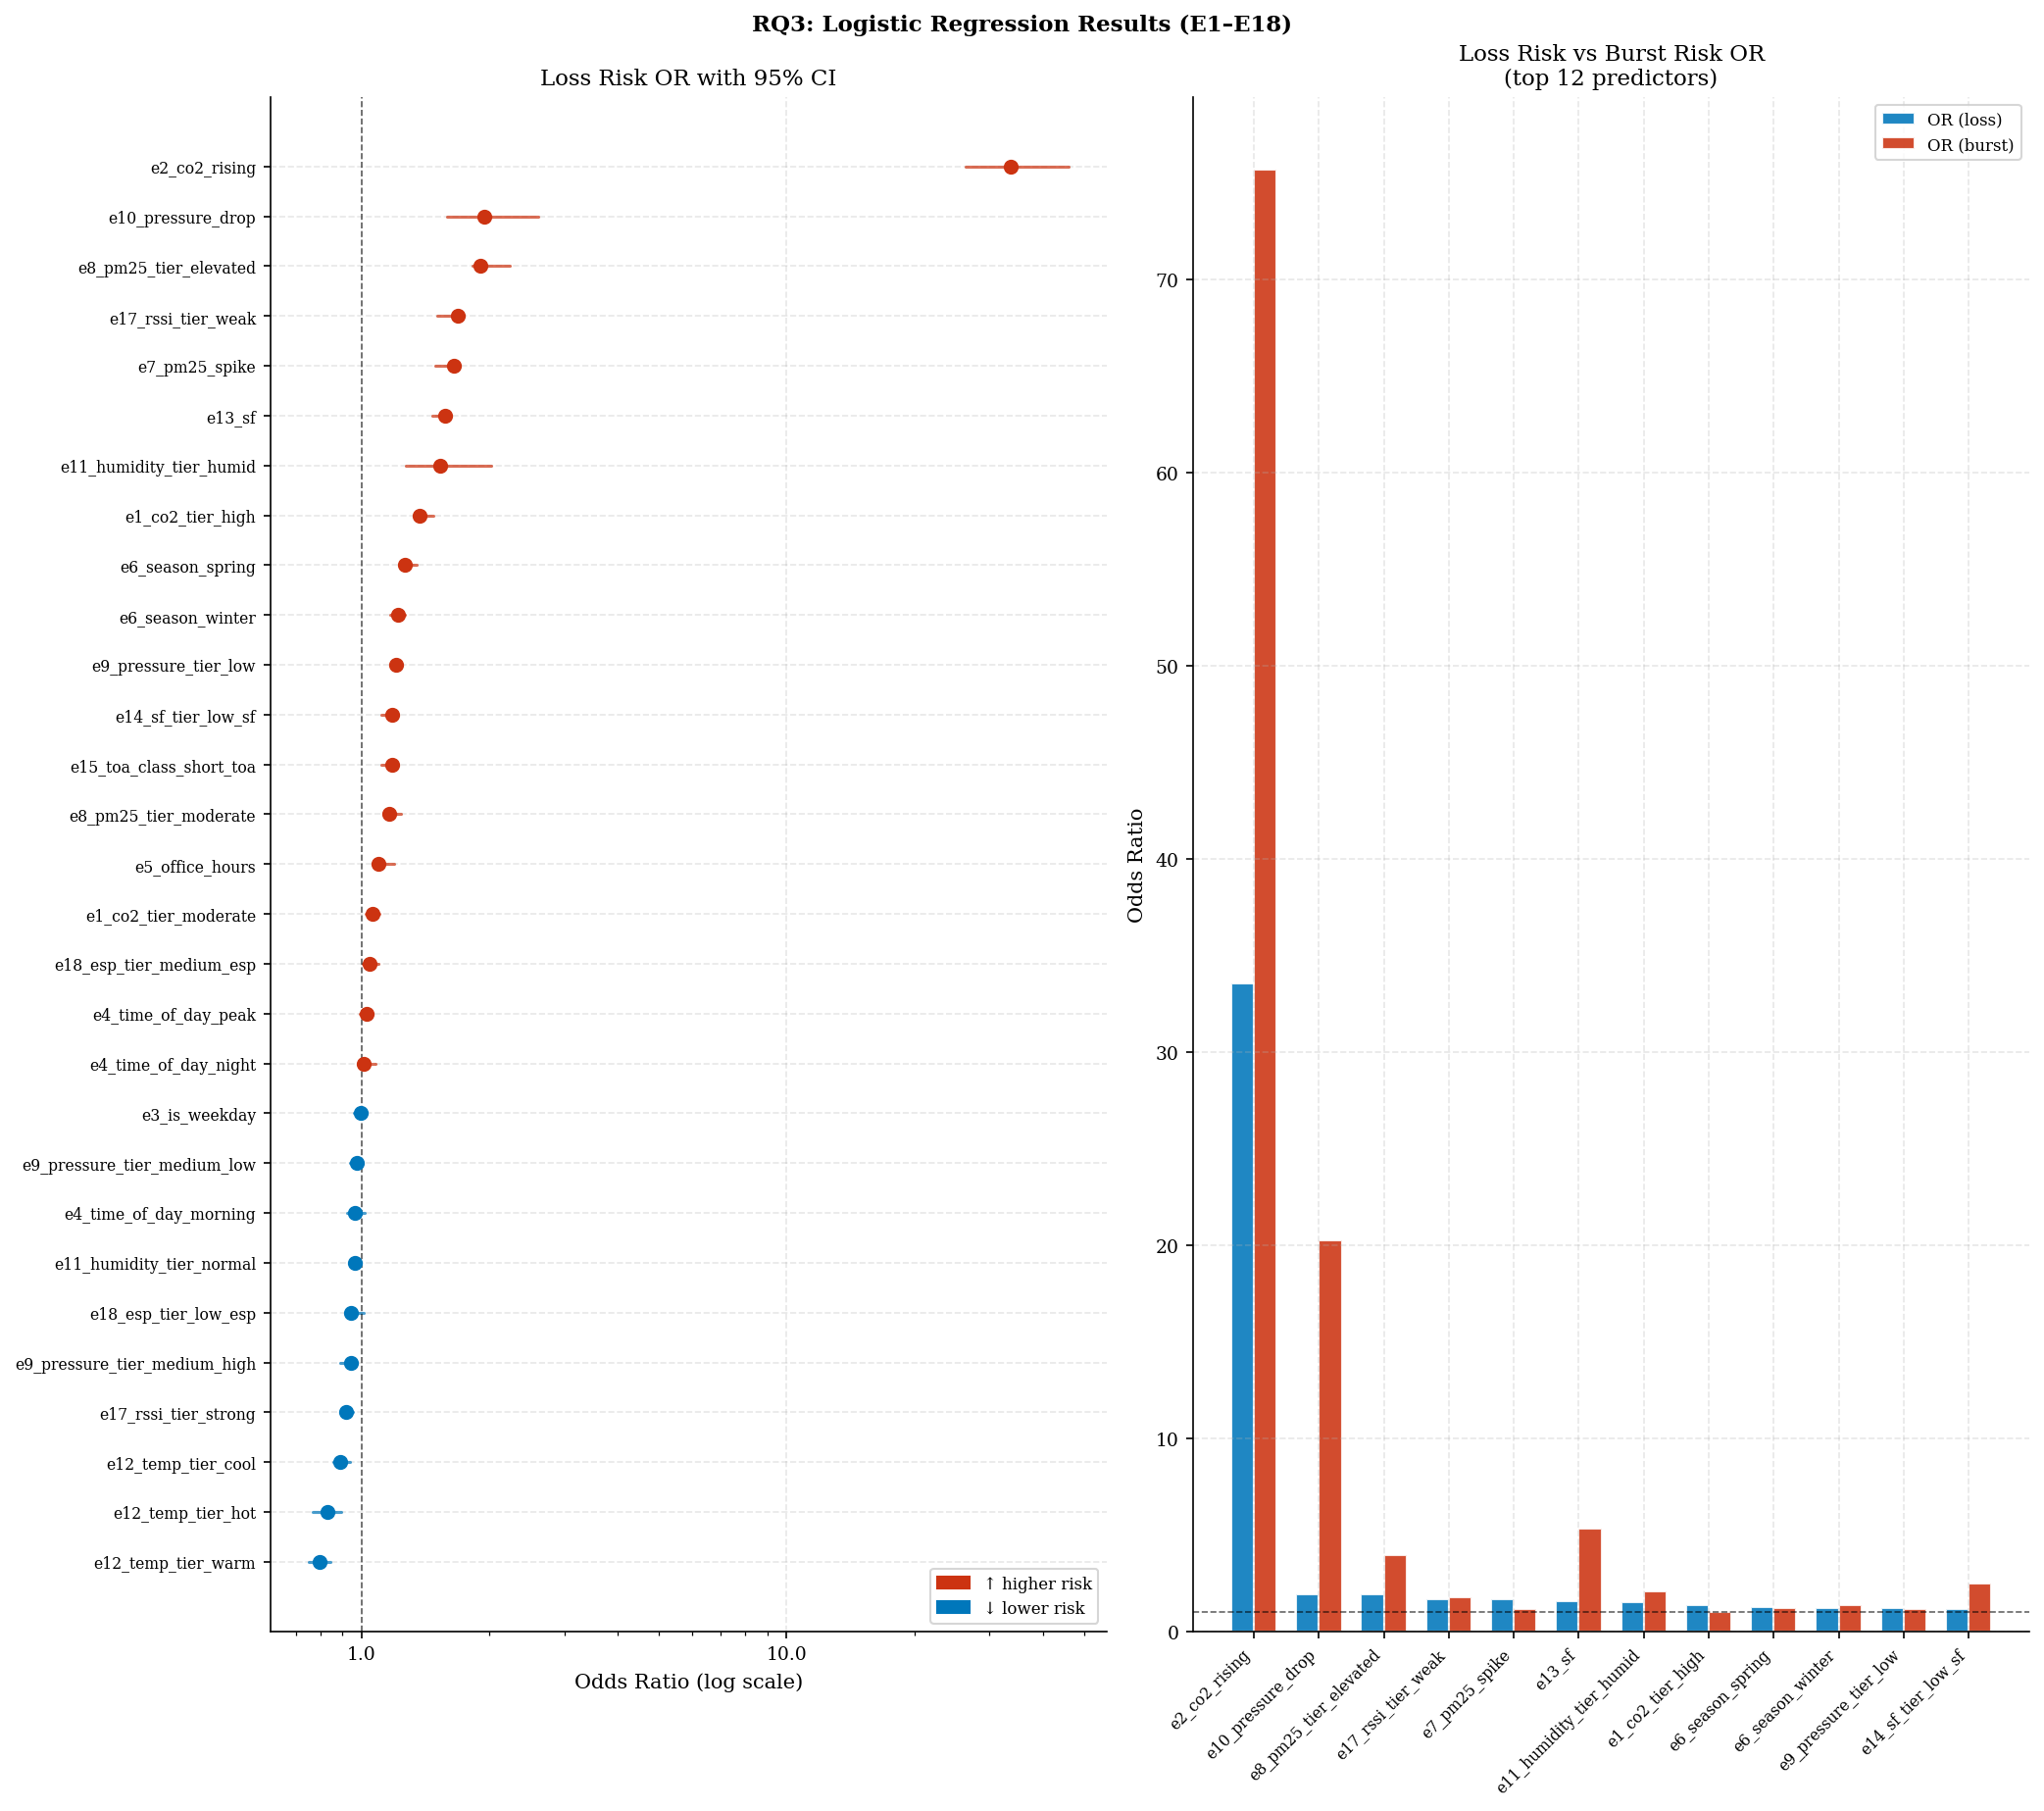

In [37]:
# Fig 03-H — Logistic Regression Forest Plot + Loss vs Burst OR
# or_table built from in-memory odds_ratios and ci_loss — no CSV dependency
# Must run after cell 34 (loss risk model) and cell 37 (burst risk model)


# build unified table from fitted models
ev_rows = []
for feat in feat_names:
    if feat.startswith('device_id'):
        continue
    ev_rows.append({
        'predictor':   feat,
        'OR_loss':     float(odds_ratios.get(feat, 1.0)),
        'loss_CI_lo':  float(ci_loss.loc[feat, 'CI_lo']) if feat in ci_loss.index else 1.0,
        'loss_CI_hi':  float(ci_loss.loc[feat, 'CI_hi']) if feat in ci_loss.index else 1.0,
        'OR_burst':    float(or_burst.get(feat, 1.0)),
        'burst_CI_lo': float(ci_burst.loc[feat, 'CI_lo']) if feat in ci_burst.index else 1.0,
        'burst_CI_hi': float(ci_burst.loc[feat, 'CI_hi']) if feat in ci_burst.index else 1.0,
    })

ev = pd.DataFrame(ev_rows)
ev_loss = ev.sort_values('OR_loss', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, len(ev_loss)*0.38+1.5))

# left: forest plot — loss risk OR with 95% CI
for i, row in ev_loss.iterrows():
    color = C['red'] if row['OR_loss'] > 1 else C['blue']
    axes[0].plot([row['loss_CI_lo'], row['loss_CI_hi']], [i, i],
                  color=color, lw=1.5, alpha=0.7, solid_capstyle='round')
    axes[0].scatter(row['OR_loss'], i, color=color, s=40, zorder=5)
axes[0].axvline(x=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
axes[0].set_yticks(range(len(ev_loss)))
axes[0].set_yticklabels(ev_loss['predictor'], fontsize=7.5)
axes[0].set_xlabel('Odds Ratio (log scale)')
axes[0].set_xscale('log')
axes[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].set_title('Loss Risk OR with 95% CI')
axes[0].legend(handles=[mpatches.Patch(color=C['red'],  label='\u2191 higher risk'),
                          mpatches.Patch(color=C['blue'], label='\u2193 lower risk')],
               loc='lower right', fontsize=8)

# right: loss vs burst OR — top 12 by loss OR
ev_top = ev.sort_values('OR_loss', ascending=False).head(12).reset_index(drop=True)
x = np.arange(len(ev_top)); w = 0.35
axes[1].bar(x-w/2, ev_top['OR_loss'],  w, color=C['blue'], alpha=0.88, label='OR (loss)',  edgecolor='white')
axes[1].bar(x+w/2, ev_top['OR_burst'], w, color=C['red'],  alpha=0.88, label='OR (burst)', edgecolor='white')
axes[1].axhline(y=1.0, color='black', lw=0.8, ls='--', alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ev_top['predictor'], rotation=45, ha='right', fontsize=7.5)
axes[1].set_ylabel('Odds Ratio')
axes[1].set_title('Loss Risk vs Burst Risk OR\n(top 12 predictors)')
axes[1].legend(fontsize=8)

fig.suptitle('RQ3: Logistic Regression Results (E1\u2013E18)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '03_h_logistic_regression')


## 12 · Key Findings Summary  *(§7 summary)*

Consolidates all results into thesis-ready statements for Chapter 7.

In [40]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

print(f"""
┌─ RQ1: Campaign-Wide Reliability ──────────────────────────┐
  PDR_system (full pipeline)  : {pdr_system:.2f}%
  PDR_raw    (radio layer)    : {pdr_raw:.2f}%
  PDR_link   (env. losses)    : {pdr_link:.2f}%
  Decomposition gap           : {pdr_link - pdr_raw:.2f} pp
  PDR range across 6 devices  : {pdr_range:.2f} pp  ← collision-dominated evidence
  Campaign duration           : 26 Sep 2024 – 22 May 2025 (238 days)
  Total intervals analysed    : {len(df_link):,}
└───────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ2: Event-Conditioned PDR ──────────────────────────────┐
  Top findings ranked by effect size r:

  {'Event':<6} {'Comparison':<35} {'Diff(pp)':>9} {'r':>8}  {'n':>10}
  {'-'*72}""")

top_events = results_df.head(6)
for _, row in top_events.iterrows():
    n_active = len(df_link[df_link.get(row['Event'], pd.Series()) == 1]) if False else ''
    print(f"  {row['Event']:<6} {row['Comparison']:<35} {row['Diff_pp']:>+8.2f} {row['Effect_r']:>8.4f}")

print(f"""
  SF × CO₂ interaction (Table 7.7 — novel finding):
    Background CO₂ : Low SF {joint_results['background']['low_sf']:.2f}%  vs  High SF {joint_results['background']['high_sf']:.2f}%  → gap = {joint_results['background']['gap']:.2f} pp
    High CO₂       : Low SF {joint_results['high']['low_sf']:.2f}%  vs  High SF {joint_results['high']['high_sf']:.2f}%  → gap = {joint_results['high']['gap']:.2f} pp
    Interaction widening: {joint_results['high']['gap'] - joint_results['background']['gap']:.2f} pp → SF×occupancy confirmed
└───────────────────────────────────────────────────────────┘
""")

print(f"""
┌─ RQ3: Strongest Predictors (Logistic Regression) ─────────┐
  AUC = {auc_loss:.3f} (loss risk)  |  AUC = {auc_burst:.3f} (burst risk)

  {'Predictor':<35} {'OR (loss)':>10} {'OR (burst)':>12}  {'Interpretation'}
  {'-'*85}""")

top_predictors = [
    ('e2_co2_rising',         'CO₂ actively rising'),
    ('e10_pressure_drop',     'Pressure drop (n=35, treat cautiously)'),
    ('e8_pm25_tier_elevated', 'Elevated PM2.5'),
    ('e17_rssi_tier_weak',    'Weak RSSI signal'),
    ('e7_pm25_spike',         'PM2.5 activity spike'),
]
for feat, label in top_predictors:
    or_l = odds_ratios.get(feat, float('nan'))
    or_b = or_burst.get(feat, float('nan'))
    print(f"  {feat:<35} {or_l:>10.3f} {or_b:>12.3f}  {label}")

print(f"""
  Device fixed effects (relative to ED0):
    ED5 OR = {odds_ratios.get('device_id_ED5', float('nan')):.3f} — 75% lower loss risk → collision hypothesis confirmed
└───────────────────────────────────────────────────────────┘
""")

KEY FINDINGS SUMMARY

┌─ RQ1: Campaign-Wide Reliability ──────────────────────────┐
  PDR_system (full pipeline)  : 59.26%
  PDR_raw    (radio layer)    : 65.83%
  PDR_link   (env. losses)    : 96.36%
  Decomposition gap           : 30.53 pp
  PDR range across 6 devices  : 0.80 pp  ← collision-dominated evidence
  Campaign duration           : 26 Sep 2024 – 22 May 2025 (238 days)
  Total intervals analysed    : 1,156,407
└───────────────────────────────────────────────────────────┘


┌─ RQ2: Event-Conditioned PDR ──────────────────────────────┐
  Top findings ranked by effect size r:

  Event  Comparison                           Diff(pp)        r           n
  ------------------------------------------------------------------------
  E10    Pressure drop vs stable               -89.72  -0.7072
  E2     CO2 rising vs stable                  -63.05  -0.3227
  E8     Elevated vs Clean PM2.5                -7.29  -0.0268
  E13    SF10 vs SF7                            -6.71  -0.0195
  E7 

## 13 · Save Results

In [41]:
# save complete event results table
results_df.to_csv(DATA_DIR / '3_results.csv', index=False)

# save OR table — loss + burst + 95% CI (Table 7.8)
or_table = pd.DataFrame({
    'predictor':    odds_ratios.index,
    'OR_loss':      odds_ratios.values,
    'loss_CI_lo':   [ci_loss.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'loss_CI_hi':   [ci_loss.loc[f, 'CI_hi'] for f in odds_ratios.index],
    'OR_burst':     [or_burst[f] for f in odds_ratios.index],
    'burst_CI_lo':  [ci_burst.loc[f, 'CI_lo'] for f in odds_ratios.index],
    'burst_CI_hi':  [ci_burst.loc[f, 'CI_hi'] for f in odds_ratios.index],
})
or_table.to_csv(DATA_DIR / '3_odds_ratios.csv', index=False)

# save joint SF x CO2 results (Table 7.7)
joint_df = pd.DataFrame(joint_results).T
joint_df.index.name = 'co2_tier'
joint_df.to_csv(DATA_DIR / '3_joint_sf_co2.csv')

print(f'Saved: {DATA_DIR / "3_results.csv"}')
print(f'Saved: {DATA_DIR / "3_odds_ratios.csv"}')
print(f'Saved: {DATA_DIR / "3_joint_sf_co2.csv"}')
print(f'\nNotebook 03 complete.')

Saved: ..\data\3_results.csv
Saved: ..\data\3_odds_ratios.csv
Saved: ..\data\3_joint_sf_co2.csv

Notebook 03 complete.
